In [10]:
import numpy as np
import pandas as pd
from scipy.stats.qmc import LatinHypercube

# ==========================================
# 1. SETUP
# ==========================================
N_SAMPLES = 8
SEED = 42  # Change this for different random batches

# Fixed Constraints
TOTAL_HEIGHT = 25.0
MIN_WEB_THICKNESS = 0.8  # 'b' minimum

# Ranges
H_BOUNDS = (12.0, 23.4)  # Inner Web Height
B_BOUNDS = (2.4, 16.0)   # Flange Width

# ==========================================
# 2. LATIN HYPERCUBE SAMPLING
# ==========================================
# We need 4 dimensions: [u_H, u_B, u_b, u_r]
# These are normalized 0-1 values that we will stretch to our ranges
sampler = LatinHypercube(d=4, seed=SEED)
u_samples = sampler.random(n=N_SAMPLES)

# ==========================================
# 3. TRANSFORM TO PHYSICAL DIMENSIONS
# ==========================================
beams = []

for u in u_samples:
    # A. Web Height (H)
    # Simple linear scaling
    H = H_BOUNDS[0] + u[0] * (H_BOUNDS[1] - H_BOUNDS[0])

    # Derived: Flange Thickness (h)
    h = (TOTAL_HEIGHT - H) / 2.0

    # B. Flange Width (B)
    # Simple linear scaling
    B = B_BOUNDS[0] + u[1] * (B_BOUNDS[1] - B_BOUNDS[0])

    # C. Web Thickness (b)
    # Constraint: b must be <= B (otherwise it's not an I-beam)
    # We scale u[2] to go from 0.8 to B
    b_max = B
    b = MIN_WEB_THICKNESS + u[2] * (b_max - MIN_WEB_THICKNESS)

    # D. Fillet Radius (r)
    # Constraint: r can only be as big as the shelf: (B - b)/2
    r_max = (B - b) / 2.0
    r = 0.0 + u[3] * (r_max - 0.0)

    beams.append({
        "H_web_height": round(H, 3),
        "h_flange_thick": round(h, 3),
        "B_flange_width": round(B, 3),
        "b_web_thick": round(b, 3),
        "r_fillet": round(r, 3),
        "Total_Height": round(H + 2*h, 3) # Check check
    })

# ==========================================
# 4. OUTPUT
# ==========================================
df = pd.DataFrame(beams)

# Reorder columns for readability
df = df[["H_web_height", "h_flange_thick", "B_flange_width", "b_web_thick", "r_fillet"]]

print("--- I-BEAM EXPERIMENT BATCH 1 ---")
print(df)

# Optional: Save to CSV
# df.to_csv("ibeam_doe_samples.csv", index=False)

--- I-BEAM EXPERIMENT BATCH 1 ---
   H_web_height  h_flange_thick  B_flange_width  b_web_thick  r_fillet
0        19.447           2.776           8.454        4.762     0.301
1        13.291           5.855          14.341        6.282     1.619
2        18.942           3.029          10.134        1.534     0.039
3        16.782           4.109          11.201        9.325     0.325
4        21.185           1.908           5.692        3.963     0.472
5        22.320           1.340           3.497        1.484     0.768
6        13.741           5.630          13.969        3.324     3.963
7        16.055           4.472           6.339        5.823     0.227


EXISTING 4 GOOD BEAMS (Str/w >= 18)
   H_web_height  h_flange_thick  B_flange_width  b_web_thick  r_fillet
0        13.291           5.855          14.341        6.282     1.619
1        16.782           4.109          11.201        9.325     0.325
2        13.741           5.630          13.969        3.324     3.963
3        19.447           2.776           8.454        4.762     0.301

Note: Eliminated beams 2, 4, 5, 7 (B too small or b too thin)

NORMALIZED EXISTING BEAMS (for distance calculation)
Shape: (4, 4)

GENERATING CANDIDATE SAMPLES
Valid candidates after constraint filtering: 644

SELECTING 6 SPACE-FILLING SAMPLES
Using greedy maximin strategy...
Selected sample 1: index 600, min_distance = 0.9686
Selected sample 2: index 466, min_distance = 0.9181
Selected sample 3: index 255, min_distance = 0.8902
Selected sample 4: index 55, min_distance = 0.7728
Selected sample 5: index 27, min_distance = 0.6576
Selected sample 6: index 204, min_distance = 0.6427

NEW 6 BEAMS TO MANUF

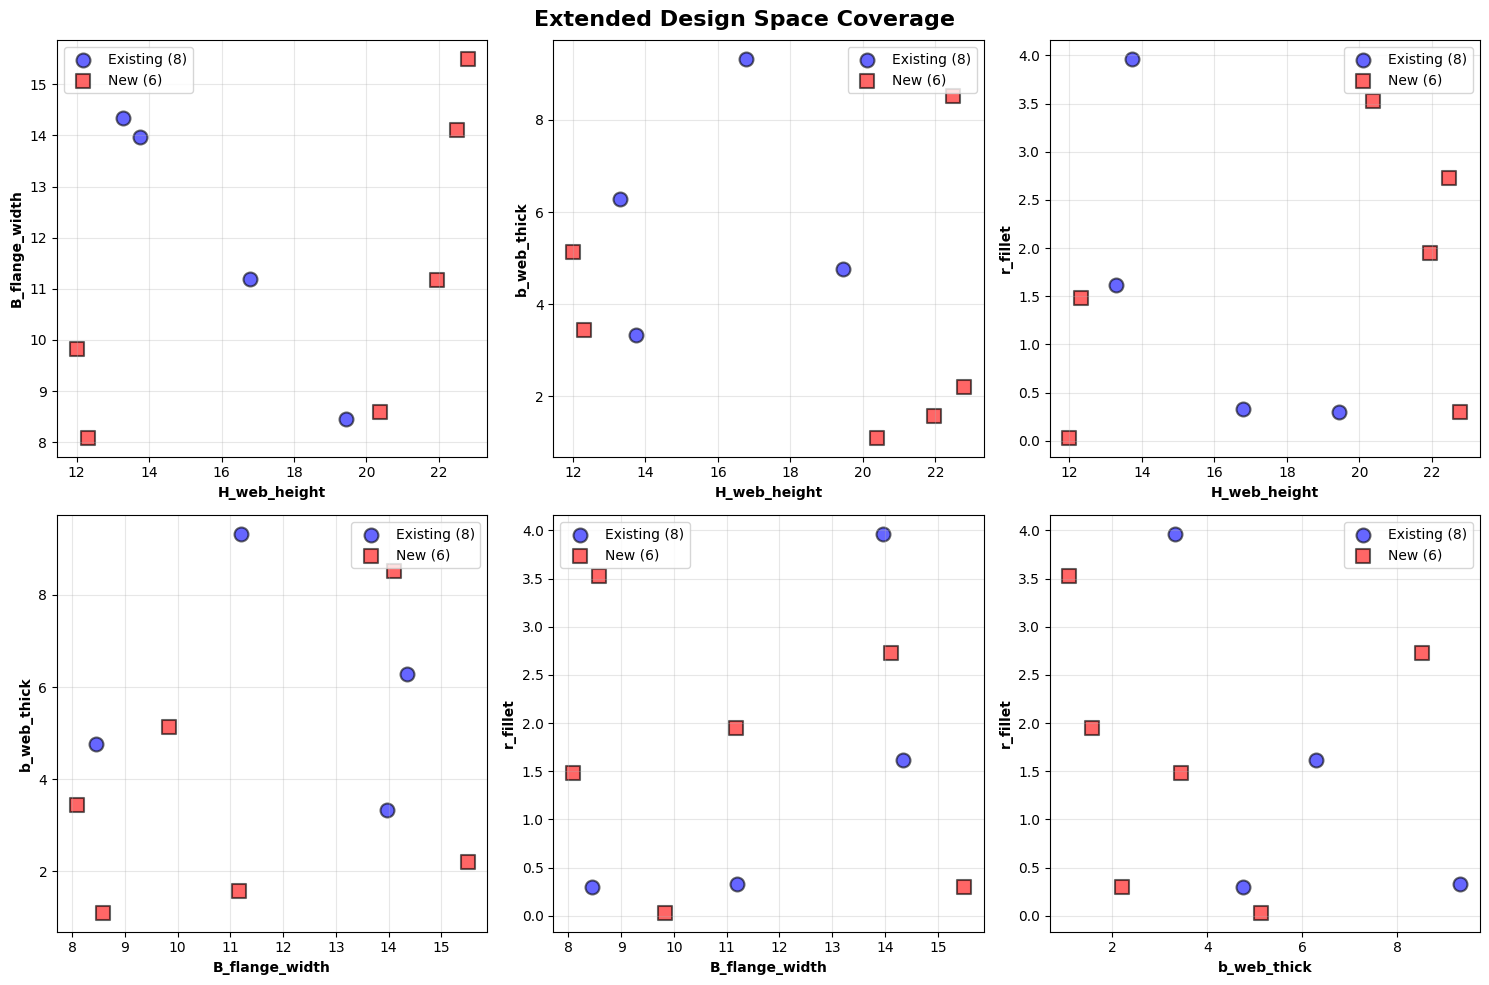

In [6]:
"""
EXTENDED LATIN HYPERCUBE SAMPLING FOR I-BEAM DESIGN
Generates 6 new space-filling samples that complement existing 8 beams
"""

import numpy as np
import pandas as pd
from scipy.stats.qmc import LatinHypercube
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

# ==========================================
# 1. EXISTING DATA
# ==========================================
# The 4 GOOD beams (Str/w >= 18) from your data + 1 untested
existing_beams = pd.DataFrame({
    "H_web_height": [13.291, 16.782, 13.741, 19.447],
    "h_flange_thick": [5.855, 4.109, 5.630, 2.776],
    "B_flange_width": [14.341, 11.201, 13.969, 8.454],
    "b_web_thick": [6.282, 9.325, 3.324, 4.762],
    "r_fillet": [1.619, 0.325, 3.963, 0.301]
})

print("="*70)
print("EXISTING 4 GOOD BEAMS (Str/w >= 18)")
print("="*70)
print(existing_beams)
print("\nNote: Eliminated beams 2, 4, 5, 7 (B too small or b too thin)")

# ==========================================
# 2. CONSTRAINTS
# ==========================================
TOTAL_HEIGHT = 25.0
MIN_WEB_THICKNESS = 0.8

H_BOUNDS = (12.0, 23.4)
B_BOUNDS = (8.0, 16.0)  # INCREASED from 2.4 to eliminate weak beams

def check_constraints(H, B, b):
    """
    Check if design satisfies all constraints
    Goal: Eliminate beams with Str/w < 18 while preserving failure mode diversity
    """
    # 1. Flange width constraint (empirically eliminates weak beams)
    #    Bad beams had B < 8: (5.692, 3.497, 6.339)
    #    Good beams had B ≥ 10: (14.341, 11.201, 13.969)
    if B < 8.0:
        return False

    # 2. Web thickness constraint (prevent overly thin webs)
    #    b should be substantial but not dominate
    #    Max at ~2/3 of B to allow web buckling/shear modes
    if b < MIN_WEB_THICKNESS or b > (2/3) * B:
        return False

    # 3. Basic sanity check
    if b > B:  # Redundant but safe
        return False

    return True

# ==========================================
# 3. NORMALIZE EXISTING BEAMS
# ==========================================
def normalize_beam(beam_dict):
    """Normalize beam parameters to [0, 1]"""
    H = beam_dict['H_web_height']
    B = beam_dict['B_flange_width']
    b = beam_dict['b_web_thick']
    r = beam_dict['r_fillet']

    # Normalize to [0, 1] using the bounds
    u_H = (H - H_BOUNDS[0]) / (H_BOUNDS[1] - H_BOUNDS[0])
    u_B = (B - B_BOUNDS[0]) / (B_BOUNDS[1] - B_BOUNDS[0])
    u_b = (b - MIN_WEB_THICKNESS) / (B - MIN_WEB_THICKNESS)  # Relative to B

    # For r, normalize relative to max possible
    r_max = (B - b) / 2.0
    u_r = r / r_max if r_max > 0 else 0.0

    return np.array([u_H, u_B, u_b, u_r])

# Normalize all existing beams
existing_normalized = np.array([
    normalize_beam(existing_beams.iloc[i].to_dict())
    for i in range(len(existing_beams))
])

print(f"\n{'='*70}")
print("NORMALIZED EXISTING BEAMS (for distance calculation)")
print(f"{'='*70}")
print(f"Shape: {existing_normalized.shape}")

# ==========================================
# 4. GENERATE CANDIDATE SAMPLES
# ==========================================
def generate_candidates(n_candidates=500, seed=42):
    """Generate many candidate samples and filter by constraints"""
    sampler = LatinHypercube(d=4, seed=seed)
    u_samples = sampler.random(n=n_candidates)

    valid_beams = []
    valid_normalized = []

    for u in u_samples:
        # Transform to physical dimensions
        H = H_BOUNDS[0] + u[0] * (H_BOUNDS[1] - H_BOUNDS[0])
        h = (TOTAL_HEIGHT - H) / 2.0
        B = B_BOUNDS[0] + u[1] * (B_BOUNDS[1] - B_BOUNDS[0])
        b_max = B
        b = MIN_WEB_THICKNESS + u[2] * (b_max - MIN_WEB_THICKNESS)
        r_max = (B - b) / 2.0
        r = 0.0 + u[3] * (r_max - 0.0)

        # Check constraints
        if check_constraints(H, B, b):
            valid_beams.append({
                "H_web_height": round(H, 3),
                "h_flange_thick": round(h, 3),
                "B_flange_width": round(B, 3),
                "b_web_thick": round(b, 3),
                "r_fillet": round(r, 3)
            })
            valid_normalized.append(u)

    return valid_beams, np.array(valid_normalized)

print(f"\n{'='*70}")
print("GENERATING CANDIDATE SAMPLES")
print(f"{'='*70}")

candidates, candidates_normalized = generate_candidates(n_candidates=1000, seed=123)
print(f"Valid candidates after constraint filtering: {len(candidates)}")

# ==========================================
# 5. SELECT SPACE-FILLING SAMPLES
# ==========================================
def select_space_filling(existing_norm, candidates_norm, n_new=6):
    """
    Select n_new samples that maximize minimum distance to existing points
    Uses greedy maximin strategy
    """
    selected_indices = []
    combined = existing_norm.copy()

    for i in range(n_new):
        # Calculate minimum distance from each candidate to all selected points
        distances = cdist(candidates_norm, combined, metric='euclidean')
        min_distances = distances.min(axis=1)

        # Select candidate with maximum minimum distance
        best_idx = min_distances.argmax()
        selected_indices.append(best_idx)

        # Add to combined set
        combined = np.vstack([combined, candidates_norm[best_idx]])

        print(f"Selected sample {i+1}: index {best_idx}, min_distance = {min_distances[best_idx]:.4f}")

    return selected_indices

print(f"\n{'='*70}")
print("SELECTING 6 SPACE-FILLING SAMPLES")
print(f"{'='*70}")
print("Using greedy maximin strategy...")

selected_indices = select_space_filling(existing_normalized, candidates_normalized, n_new=6)

new_beams = [candidates[idx] for idx in selected_indices]
new_beams_df = pd.DataFrame(new_beams)

print(f"\n{'='*70}")
print("NEW 6 BEAMS TO MANUFACTURE")
print(f"{'='*70}")
print(new_beams_df)

# ==========================================
# 6. COMBINED DATASET
# ==========================================
all_beams = pd.concat([existing_beams, new_beams_df], ignore_index=True)
all_beams['Batch'] = ['Existing']*4 + ['New']*6

print(f"\n{'='*70}")
print("ALL 10 BEAMS (4 existing + 6 new)")
print(f"{'='*70}")
print(all_beams)

# Save to CSV
output_file = "ibeam_extended_doe.csv"
all_beams.to_csv(output_file, index=False)
print(f"\n✓ Saved to: {output_file}")

# ==========================================
# 7. VISUALIZE SPACE-FILLING PROPERTY
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Extended Design Space Coverage', fontsize=16, fontweight='bold')

param_names = ['H_web_height', 'B_flange_width', 'b_web_thick', 'r_fillet']
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

for ax, (i, j) in zip(axes.flat, pairs):
    # Plot existing beams
    ax.scatter(existing_beams[param_names[i]],
               existing_beams[param_names[j]],
               c='blue', s=100, alpha=0.6, label='Existing (8)',
               edgecolors='black', linewidth=1.5)

    # Plot new beams
    ax.scatter(new_beams_df[param_names[i]],
               new_beams_df[param_names[j]],
               c='red', s=100, alpha=0.6, label='New (6)',
               marker='s', edgecolors='black', linewidth=1.5)

    ax.set_xlabel(param_names[i], fontweight='bold')
    ax.set_ylabel(param_names[j], fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ibeam_extended_space_filling.png', dpi=150, bbox_inches='tight')
print(f"✓ Saved visualization to: ibeam_extended_space_filling.png")

# ==========================================
# 8. STATISTICS
# ==========================================
print(f"\n{'='*70}")
print("DESIGN SPACE STATISTICS")
print(f"{'='*70}")

for param in param_names:
    existing_range = existing_beams[param].max() - existing_beams[param].min()
    new_range = new_beams_df[param].max() - new_beams_df[param].min()
    combined_range = all_beams[param].max() - all_beams[param].min()

    print(f"\n{param}:")
    print(f"  Existing coverage: {existing_range:.3f}")
    print(f"  New coverage: {new_range:.3f}")
    print(f"  Combined coverage: {combined_range:.3f}")

# Check constraint satisfaction
print(f"\n{'='*70}")
print("CONSTRAINT VERIFICATION")
print(f"{'='*70}")
print("\nAll new beams satisfy:")
print("  ✓ B ≥ 8.0 mm (adequate flange width)")
print("  ✓ b ≤ (2/3)B (allows web failure modes)")
print("  ✓ b ≥ 0.8 mm (minimum web thickness)")
print("  ✓ H + 2h = 25.0 (total height)")
print("  ✓ r ≤ (B-b)/2 (fillet radius)")

print("\nExpected failure mode diversity:")
print("  - Web buckling: small b, large H")
print("  - Flange buckling: smaller B, larger H")
print("  - Tipping: larger H/B ratios (up to ~3)")
print("  - Balanced designs: moderate all parameters")

for idx, beam in new_beams_df.iterrows():
    H = beam['H_web_height']
    B = beam['B_flange_width']
    b = beam['b_web_thick']
    h = beam['h_flange_thick']
    ratio = H / B
    b_ratio = b / B
    print(f"\nBeam {idx+1}: H/B = {ratio:.2f}, b/B = {b_ratio:.2f}, h/H = {h/H:.2f}")

print(f"\n{'='*70}")
print("✓ DONE - Ready for manufacturing and testing!")
print(f"{'='*70}")

In [7]:
"""
BAYESIAN OPTIMIZATION FOR I-BEAM STRENGTH-TO-WEIGHT RATIO

Starting with initial samples from the I-beam dataset.
Goal: Find optimal beam configuration using UCB and EI acquisition functions.
"""

import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
import os
import urllib.request

warnings.filterwarnings("ignore")

# ==========================================
# DOWNLOAD DATA
# ==========================================
def download(url, local_filename=None):
    """Download a file from a direct URL."""
    if local_filename is None:
        local_filename = os.path.basename(url)

    print(f"Downloading {local_filename}...")
    try:
        urllib.request.urlretrieve(url, local_filename)
        print("✓ Download complete!")
    except Exception as e:
        print(f"✗ Error downloading file: {e}")

# GitHub Raw URL for I-beam data
DATA_URL = "https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/data/I_beam_data.csv"
CSV_FILE = "I_beam_data.csv"

# Download if not already present
if not os.path.exists(CSV_FILE):
    download(DATA_URL, CSV_FILE)
else:
    print(f"✓ {CSV_FILE} already exists")

# ==========================================
# CONFIGURATION
# ==========================================
# Column mappings for I-beam data (FIXED to match actual CSV)
COL_MAP = {
    'height': 'H_web_height',
    'width': 'B_flange_width',
    'center_width': 'b_web_thick',
    'wall_thickness': 'h_flange_thick',
    'target': 'Str/w (N/g)'
}

# Design space bounds (based on your data)
BOUNDS = {
    'height': (13, 23),           # H_web_height range
    'width': (3, 15),              # B_flange_width range
    'center_width': (1, 10),       # b_web_thick range
    'wall_thickness': (1, 6)       # h_flange_thick range
}

PARAM_NAMES = ['H_web_height', 'B_flange_width', 'b_web_thick', 'h_flange_thick']

# ==========================================
# DATA PROCESSING
# ==========================================
def load_and_process_data(csv_path):
    """Load I-beam data"""
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Could not find {csv_path}")

    df = pd.read_csv(csv_path)

    print("\n" + "="*70)
    print("LOADED DATA")
    print("="*70)
    print(f"Columns available: {df.columns.tolist()}")
    print(f"Number of samples: {len(df)}")

    # Check if Str/w column exists
    if COL_MAP['target'] not in df.columns:
        raise ValueError(f"'{COL_MAP['target']}' column not found in CSV!")

    # Extract features and remove any rows with NaN values
    feature_cols = [COL_MAP['height'], COL_MAP['width'],
                    COL_MAP['center_width'], COL_MAP['wall_thickness']]

    # Create a clean dataframe with only the columns we need
    df_clean = df[feature_cols + [COL_MAP['target']]].copy()

    # Check for NaN values
    print(f"\nChecking for missing values...")
    print(f"  Rows before cleaning: {len(df_clean)}")
    print(f"  Missing values per column:")
    for col in feature_cols + [COL_MAP['target']]:
        n_missing = df_clean[col].isna().sum()
        print(f"    {col}: {n_missing}")

    # Drop rows with any NaN values
    df_clean = df_clean.dropna()
    print(f"  Rows after cleaning: {len(df_clean)}")

    if len(df_clean) == 0:
        raise ValueError("No valid data remaining after removing NaN values!")

    # Extract features
    X = df_clean[feature_cols].values
    y = df_clean[COL_MAP['target']].values.astype(float)

    print(f"\nFeature ranges:")
    print(f"  H_web_height: [{X[:, 0].min():.3f}, {X[:, 0].max():.3f}] mm")
    print(f"  B_flange_width: [{X[:, 1].min():.3f}, {X[:, 1].max():.3f}] mm")
    print(f"  b_web_thick: [{X[:, 2].min():.3f}, {X[:, 2].max():.3f}] mm")
    print(f"  h_flange_thick: [{X[:, 3].min():.3f}, {X[:, 3].max():.3f}] mm")
    print(f"\nStr/w range: [{y.min():.2f}, {y.max():.2f}] N/g")

    # Update bounds based on actual data
    global BOUNDS
    BOUNDS = {
        'height': (X[:, 0].min() * 0.9, X[:, 0].max() * 1.1),
        'width': (X[:, 1].min() * 0.9, X[:, 1].max() * 1.1),
        'center_width': (X[:, 2].min() * 0.9, X[:, 2].max() * 1.1),
        'wall_thickness': (X[:, 3].min() * 0.9, X[:, 3].max() * 1.1)
    }
    print(f"\nUpdated bounds (±10% from data):")
    for key, (lo, hi) in BOUNDS.items():
        print(f"  {key}: [{lo:.3f}, {hi:.3f}]")

    return X, y, df_clean

def normalize(X, bounds=BOUNDS):
    """Normalize features to [0, 1]"""
    X_n = np.copy(X).astype(float)
    keys = list(bounds.keys())
    for i, k in enumerate(keys):
        X_n[:,i] = (X[:,i] - bounds[k][0]) / (bounds[k][1] - bounds[k][0])
    return X_n

def denormalize(X_n, bounds=BOUNDS):
    """Denormalize features back to original scale"""
    X = np.copy(X_n)
    keys = list(bounds.keys())
    for i, k in enumerate(keys):
        X[:,i] = X_n[:,i] * (bounds[k][1] - bounds[k][0]) + bounds[k][0]
    return X

# ==========================================
# GP TRAINING
# ==========================================
def train_gp(X, y, alpha=1e-4):
    """Train Gaussian Process with Matern kernel"""
    X_norm = normalize(X)
    y_log = np.log(y)
    y_mean = np.mean(y_log)
    y_centered = y_log - y_mean

    n_samples = len(X)
    n_dims = X.shape[1]
    samples_per_dim = n_samples / n_dims

    # Adaptive length scale bounds based on data quantity
    if samples_per_dim < 4:
        ls_bounds = (0.3, 5.0)
        strategy = "EXPLORATION (sparse data)"
    elif samples_per_dim < 10:
        ls_bounds = (0.15, 3.0)
        strategy = "BALANCED"
    else:
        ls_bounds = (0.05, 10.0)
        strategy = "EXPLOITATION (sufficient data)"

    print(f"\n{'='*70}")
    print(f"GP TRAINING")
    print(f"{'='*70}")
    print(f"Samples: {n_samples} ({samples_per_dim:.1f} per dimension)")
    print(f"Strategy: {strategy}")
    print(f"Length scale bounds: [{ls_bounds[0]:.2f}, {ls_bounds[1]:.2f}]")
    print(f"Noise level (α): {alpha:.1e}")

    # Build kernel
    kernel = ConstantKernel(1.0) * Matern(
        length_scale=[0.5]*n_dims,
        length_scale_bounds=ls_bounds,
        nu=2.5
    )

    # Train GP
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=25,
        alpha=alpha,
        normalize_y=False
    )
    gp.fit(X_norm, y_centered)

    # Print learned length scales (ARD)
    scales = gp.kernel_.k2.length_scale
    print(f"\nLearned length scales (ARD):")
    for name, scale in zip(PARAM_NAMES, scales):
        if scale < 0.2:
            status = "VERY SENSITIVE"
        elif scale < 1.0:
            status = "High Influence"
        elif scale > 3.0:
            status = "Low Influence"
        else:
            status = "Moderate"
        print(f"  {name:<20}: {scale:>8.4f}  ({status})")

    return gp, X_norm, y_centered, y_mean

# ==========================================
# ACQUISITION FUNCTIONS
# ==========================================
def optimize_acquisition(gp, y_temp, acq_type='ei', kappa=3.0, n_starts=30):
    """Optimize acquisition function"""

    if acq_type == 'ei':
        best_y = np.max(y_temp)

        def neg_acq(x):
            x_in = x.reshape(1, -1)
            mu, sigma = gp.predict(x_in, return_std=True)
            if sigma < 1e-9:
                return 0.0
            Z = (mu - best_y) / sigma
            ei = (mu - best_y) * norm.cdf(Z) + sigma * norm.pdf(Z)
            return -ei.item()

    else:  # ucb
        def neg_acq(x):
            x_in = x.reshape(1, -1)
            mu, sigma = gp.predict(x_in, return_std=True)
            ucb = mu + (kappa * sigma)
            return -ucb.item()

    # Multi-start optimization
    best_x = None
    best_score = 1e10

    n_dims = len(gp.X_train_[0])
    for _ in range(n_starts):
        x0 = np.random.uniform(0, 1, n_dims)
        res = minimize(neg_acq, x0, bounds=[(0,1)]*n_dims, method='L-BFGS-B')
        if res.fun < best_score:
            best_score = res.fun
            best_x = res.x

    return best_x

def get_top_suggestions(gp, X_norm, y_centered, y_mean, acq_type='ei', kappa=3.0, n_suggestions=3):
    """Get top N suggestions using sequential kriging"""
    suggestions = []
    preds = []

    X_temp = X_norm.copy()
    y_temp = y_centered.copy()

    for i in range(n_suggestions):
        # Re-fit GP with fantasized points
        kernel = ConstantKernel(1.0) * Matern(
            length_scale=gp.kernel_.k2.length_scale,
            length_scale_bounds=gp.kernel_.k2.length_scale_bounds,
            nu=2.5
        )
        gp_temp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=3,
            alpha=gp.alpha,
            normalize_y=False
        )
        gp_temp.fit(X_temp, y_temp)

        # Optimize acquisition
        best_x = optimize_acquisition(gp_temp, y_temp, acq_type, kappa)
        suggestions.append(best_x)

        # Fantasize: assume predicted mean
        mu_pred, _ = gp_temp.predict(best_x.reshape(1, -1), return_std=True)
        preds.append(np.exp(mu_pred + y_mean).item())

        X_temp = np.vstack([X_temp, best_x])
        y_temp = np.append(y_temp, mu_pred)

    return suggestions, preds

# ==========================================
# OUTPUT FORMATTING
# ==========================================
def round_to_practical(X):
    """Round to practical manufacturing values"""
    X_r = X.copy()
    X_r[0] = np.round(X_r[0], 2)   # Height to 0.01mm
    X_r[1] = np.round(X_r[1], 2)   # Width to 0.01mm
    X_r[2] = np.round(X_r[2], 2)   # Web width to 0.01mm
    X_r[3] = np.round(X_r[3], 2)   # Wall thickness to 0.01mm

    # Clip to bounds
    keys = list(BOUNDS.keys())
    for i, k in enumerate(keys):
        X_r[i] = np.clip(X_r[i], BOUNDS[k][0], BOUNDS[k][1])

    return X_r

def print_recommendations(title, suggestions, preds, labels=None):
    """Print recommendations in formatted table"""
    print(f"\n{title}")
    print(f"{'Type':<12} {'H_web':<8} {'B_flange':<8} {'b_web':<8} {'h_flange':<8} | {'Pred Str/w':<10}")
    print("-" * 65)

    if labels is None:
        labels = [f"#{i+1}" for i in range(len(suggestions))]

    for label, s, p in zip(labels, suggestions, preds):
        s_denorm = denormalize(s.reshape(1, -1))[0]
        s_rounded = round_to_practical(s_denorm)
        print(f"{label:<12} {s_rounded[0]:<8.2f} {s_rounded[1]:<8.2f} "
              f"{s_rounded[2]:<8.2f} {s_rounded[3]:<8.2f} | {p:<10.2f}")

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    print("\n" + "="*70)
    print("I-BEAM BAYESIAN OPTIMIZATION")
    print("="*70)

    # Load data
    X, y, df = load_and_process_data(CSV_FILE)

    # Train GP with moderate noise assumption
    gp, X_norm, y_centered, y_mean = train_gp(X, y, alpha=1e-4)

    # Strategy 1: Expected Improvement
    print("\n" + "="*70)
    print("STRATEGY 1: Expected Improvement (EI)")
    print("="*70)
    print("Sequential kriging with constant liar strategy")

    ei_suggestions, ei_preds = get_top_suggestions(
        gp, X_norm, y_centered, y_mean,
        acq_type='ei',
        n_suggestions=3
    )
    ei_labels = ["EI #1", "EI #2", "EI #3"]
    print_recommendations("🎯 Top 3 EI Recommendations:", ei_suggestions, ei_preds, ei_labels)

    # Strategy 2: Upper Confidence Bound
    print("\n" + "="*70)
    print("STRATEGY 2: Upper Confidence Bound (UCB)")
    print("="*70)
    print("Sequential kriging with UCB (κ=3.0)")

    ucb_suggestions, ucb_preds = get_top_suggestions(
        gp, X_norm, y_centered, y_mean,
        acq_type='ucb',
        kappa=3.0,
        n_suggestions=3
    )
    ucb_labels = ["UCB #1", "UCB #2", "UCB #3"]
    print_recommendations("🎯 Top 3 UCB Recommendations:", ucb_suggestions, ucb_preds, ucb_labels)

    # Combined recommendations
    print("\n" + "="*70)
    print("COMBINED RECOMMENDATIONS: 6 BEAMS")
    print("="*70)

    all_suggestions = ei_suggestions + ucb_suggestions
    all_preds = ei_preds + ucb_preds
    all_labels = ei_labels + ucb_labels

    print_recommendations("🎯 All 6 Recommended Beams:", all_suggestions, all_preds, all_labels)

    # Save recommendations
    all_suggestions_denorm = np.array([denormalize(s.reshape(1, -1))[0] for s in all_suggestions])
    all_suggestions_rounded = np.array([round_to_practical(s) for s in all_suggestions_denorm])

    df_recommendations = pd.DataFrame(
        all_suggestions_rounded,
        columns=['H_web_height', 'B_flange_width', 'b_web_thick', 'h_flange_thick']
    )
    df_recommendations.insert(0, 'Type', all_labels)
    df_recommendations['Predicted Str/w (N/g)'] = [f"{p:.2f}" for p in all_preds]

    output_file = "i_beam_recommendations.csv"
    df_recommendations.to_csv(output_file, index=False)
    print(f"\n✓ Saved recommendations to: {output_file}")

    # Save for plotting
    np.save("i_beam_recommendations_norm.npy", np.array(all_suggestions))
    np.save("i_beam_labels.npy", np.array(all_labels))
    print("✓ Saved normalized recommendations for plotting")

    # Diversity check
    print("\n📊 Diversity Check:")
    print(f"  Unique H_web_height: {len(np.unique(np.round(all_suggestions_rounded[:, 0], 1)))}")
    print(f"  Unique B_flange_width: {len(np.unique(np.round(all_suggestions_rounded[:, 1], 1)))}")
    print(f"  Unique b_web_thick: {len(np.unique(np.round(all_suggestions_rounded[:, 2], 2)))}")
    print(f"  Unique h_flange_thick: {len(np.unique(np.round(all_suggestions_rounded[:, 3], 2)))}")

    print("\n" + "="*70)
    print("✓ ANALYSIS COMPLETE")
    print("="*70)
    print("\nNext steps:")
    print("1. Manufacture the 6 recommended beams")
    print("2. Test their strength-to-weight ratios")
    print("3. Add results to the dataset")
    print("4. Re-run this script to refine recommendations")
    print("="*70)

✓ I_beam_data.csv already exists

I-BEAM BAYESIAN OPTIMIZATION

LOADED DATA
Columns available: ['Index', 'H_web_height', 'h_flange_thick', 'B_flange_width', 'b_web_thick', 'r_fillet', 'Material', 'Str/w (N/g)', 'G', 'N', 'Column 11', 'Unnamed: 11']
Number of samples: 14

Checking for missing values...
  Rows before cleaning: 14
  Missing values per column:
    H_web_height: 0
    B_flange_width: 0
    b_web_thick: 0
    h_flange_thick: 0
    Str/w (N/g): 0
  Rows after cleaning: 14

Feature ranges:
  H_web_height: [12.001, 22.791] mm
  B_flange_width: [3.497, 15.497] mm
  b_web_thick: [1.102, 9.325] mm
  h_flange_thick: [1.105, 6.500] mm

Str/w range: [0.91, 33.45] N/g

Updated bounds (±10% from data):
  height: [10.801, 25.070]
  width: [3.147, 17.047]
  center_width: [0.992, 10.258]
  wall_thickness: [0.995, 7.150]

GP TRAINING
Samples: 14 (3.5 per dimension)
Strategy: EXPLORATION (sparse data)
Length scale bounds: [0.30, 5.00]
Noise level (α): 1.0e-04

Learned length scales (ARD):
 

In [8]:
"""
BAYESIAN OPTIMIZATION FOR I-BEAM STRENGTH-TO-WEIGHT RATIO
4D Design Space: H_web_height, B_flange_width, b_web_thick, r_fillet
(h_flange_thick is derived: h = (25 - H) / 2)

Based on sensitivity analysis: UCB + Matern + ARD + adaptive κ + noise=1e-3 (log-space)

Challenge Structure:
- Start with initial beams meeting geometric constraints
- Round 1: BO suggests 3 beams → manufacture & test
- Round 2: BO suggests 3 more beams → manufacture & test
- Round 3: Final 3 beams → manufacture & test (includes best prediction)

Goal: Find the highest Str/w beam vs human intuition
"""

import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
import matplotlib.pyplot as plt
from datetime import datetime

warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION
# ==========================================
# Design constraints - GEOMETRIC ONLY
TOTAL_HEIGHT = 25.0
MIN_WEB_THICKNESS = 0.8
MIN_FLANGE_WIDTH = 8.0  # B ≥ 8 mm
MAX_WEB_RATIO = 2/3     # b ≤ (2/3)*B

# Design space bounds (4D - h is derived from H)
BOUNDS = {
    'H_web_height': (12.0, 23.4),
    'B_flange_width': (8.0, 16.0),      # Constrained to B ≥ 8
    'b_web_thick': (0.8, 10.67),        # b ≤ (2/3)*B_max = 10.67
    'r_fillet': (0.0, 4.0)              # Max is (B-b)/2, ~4mm for typical beams
}

PARAM_NAMES = ['H_web_height', 'B_flange_width', 'b_web_thick', 'r_fillet']
N_DIMS = 4  # Reduced from 5

# BO Configuration (from sensitivity study)
BO_CONFIG = {
    'kernel': 'Matern',
    'nu': 2.5,
    'use_ARD': True,
    'acquisition': 'UCB',
    'noise_log': 1e-3,  # High noise assumption in log-space
    'kappa_schedule': {
        'round_1': 2.5,  # More exploration early on (14 samples)
        'round_2': 2.0,  # Balanced (17 samples)
        'round_3': 1.5   # More exploitation (20 samples)
    }
}

# ==========================================
# CONSTRAINT CHECKING
# ==========================================
def check_constraints(H, B, b, r):
    """
    Check if design satisfies GEOMETRIC constraints only
    (Does NOT filter by Str/w performance)
    """
    # Derive h from H
    h = (TOTAL_HEIGHT - H) / 2.0

    # 1. Flange width minimum
    if B < MIN_FLANGE_WIDTH:
        return False

    # 2. Web thickness constraints
    if b < MIN_WEB_THICKNESS or b > MAX_WEB_RATIO * B:
        return False

    # 3. Fillet radius constraint
    r_max = (B - b) / 2.0
    if r < 0 or r > r_max:
        return False

    # 4. Sanity checks
    if b > B or h < 0 or h > 6.5:
        return False

    return True

def enforce_constraints(params):
    """Enforce geometric constraints on 4D parameters"""
    H, B, b, r = params

    # Derive h from H (not a free parameter)
    h = (TOTAL_HEIGHT - H) / 2.0

    # Clip to bounds
    H = np.clip(H, BOUNDS['H_web_height'][0], BOUNDS['H_web_height'][1])
    B = np.clip(B, BOUNDS['B_flange_width'][0], BOUNDS['B_flange_width'][1])
    b = np.clip(b, MIN_WEB_THICKNESS, min(MAX_WEB_RATIO*B, BOUNDS['b_web_thick'][1]))

    # Fillet constraint
    r_max = (B - b) / 2.0
    r = np.clip(r, 0, min(r_max, BOUNDS['r_fillet'][1]))

    # Recalculate h after H adjustment
    h = (TOTAL_HEIGHT - H) / 2.0

    return np.array([H, B, b, r]), h

# ==========================================
# DATA NORMALIZATION
# ==========================================
def normalize(X, bounds=BOUNDS):
    """Normalize features to [0, 1]"""
    X_n = np.copy(X).astype(float)
    param_names = list(bounds.keys())
    for i, name in enumerate(param_names):
        X_n[:, i] = (X[:, i] - bounds[name][0]) / (bounds[name][1] - bounds[name][0])
    return X_n

def denormalize(X_n, bounds=BOUNDS):
    """Denormalize features back to original scale"""
    X = np.copy(X_n)
    param_names = list(bounds.keys())
    for i, name in enumerate(param_names):
        X[:, i] = X_n[:, i] * (bounds[name][1] - bounds[name][0]) + bounds[name][0]
    return X

# ==========================================
# GAUSSIAN PROCESS TRAINING
# ==========================================
def train_gp(X, y, round_num=1, alpha=1e-3, use_param_specific_ard=True):
    """
    Train Gaussian Process with Matern kernel (ARD)
    Uses log-space for y with high noise assumption

    ARD Strategy:
    - Each parameter gets its own length scale
    - Bounds adapt based on sample size
    - Optionally use parameter-specific bounds based on engineering knowledge
    """
    X_norm = normalize(X)

    # Log-transform target (Str/w is multiplicative)
    y_log = np.log(y)
    y_mean = np.mean(y_log)
    y_centered = y_log - y_mean

    n_samples = len(X)
    n_dims = X.shape[1]
    samples_per_dim = n_samples / n_dims

    # Adaptive length scale bounds based on data quantity
    if samples_per_dim < 4:
        base_ls_bounds = (0.3, 5.0)
        strategy = "EXPLORATION"
    elif samples_per_dim < 6:
        base_ls_bounds = (0.2, 4.0)
        strategy = "BALANCED"
    else:
        base_ls_bounds = (0.1, 3.0)
        strategy = "EXPLOITATION"

    print(f"\n{'='*70}")
    print(f"GP TRAINING - ROUND {round_num}")
    print(f"{'='*70}")
    print(f"Samples: {n_samples} ({samples_per_dim:.2f} per dimension)")
    print(f"Strategy: {strategy}")
    print(f"Base length scale bounds: [{base_ls_bounds[0]:.2f}, {base_ls_bounds[1]:.2f}]")
    print(f"Noise level (α): {alpha:.1e} (log-space)")

    # Parameter-specific ARD bounds (optional refinement)
    if use_param_specific_ard:
        # Engineering intuition for 4D space:
        # - H strongly affects moment of inertia → HIGH sensitivity
        # - B strongly affects flange contribution → HIGH sensitivity
        # - b affects web buckling/shear → MODERATE sensitivity
        # - r has localized effect → LOWER sensitivity

        param_bounds = {
            'H_web_height': (base_ls_bounds[0] * 0.7, base_ls_bounds[1] * 0.9),  # Expect high influence
            'B_flange_width': (base_ls_bounds[0] * 0.7, base_ls_bounds[1] * 0.9), # Expect high influence
            'b_web_thick': (base_ls_bounds[0] * 1.0, base_ls_bounds[1] * 1.0),    # Moderate
            'r_fillet': (base_ls_bounds[0] * 1.3, base_ls_bounds[1] * 1.2)        # Expect lower influence
        }

        ls_bounds_list = [param_bounds[name] for name in PARAM_NAMES]
        print(f"\nParameter-specific ARD bounds (engineering-informed):")
        for name, bounds in zip(PARAM_NAMES, ls_bounds_list):
            print(f"  {name:<20}: [{bounds[0]:.3f}, {bounds[1]:.3f}]")
    else:
        ls_bounds_list = base_ls_bounds

    # Build Matern kernel with ARD
    # Each parameter gets its own length scale that GP will optimize
    kernel = ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0)) * Matern(
        length_scale=[0.5] * n_dims,
        length_scale_bounds=ls_bounds_list,
        nu=2.5
    )

    # Train GP
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=25,
        alpha=alpha,
        normalize_y=False
    )
    gp.fit(X_norm, y_centered)

    # Analyze learned length scales (ARD interpretation)
    scales = gp.kernel_.k2.length_scale
    print(f"\nLearned ARD length scales:")
    for name, scale in zip(PARAM_NAMES, scales):
        if scale < 0.3:
            status = "⚡ VERY SENSITIVE"
        elif scale < 0.8:
            status = "🔥 High Influence"
        elif scale > 2.0:
            status = "💤 Low Influence"
        else:
            status = "⚖️  Moderate"
        print(f"  {name:<20}: {scale:>8.4f}  {status}")

    # Print kernel parameters
    const_val = gp.kernel_.k1.constant_value
    print(f"\nKernel constant: {const_val:.4f}")
    print(f"Effective noise variance: {alpha:.1e}")

    return gp, X_norm, y_centered, y_mean

# ==========================================
# ACQUISITION FUNCTIONS
# ==========================================
def ucb_acquisition(gp, X_norm_candidate, kappa):
    """Upper Confidence Bound acquisition"""
    mu, sigma = gp.predict(X_norm_candidate, return_std=True)
    ucb = mu + kappa * sigma
    return ucb, mu, sigma

def optimize_acquisition_ucb(gp, kappa, n_starts=50, n_candidates=500):
    """
    Optimize UCB acquisition function
    Uses constraint-aware random search + local optimization
    Works with 4D space (h is derived from H)
    """
    best_x = None
    best_ucb = -np.inf
    best_mu = None
    best_sigma = None

    # Generate constraint-satisfying candidates
    valid_candidates = []
    valid_normalized = []

    attempts = 0
    max_attempts = 5000

    while len(valid_candidates) < n_candidates and attempts < max_attempts:
        attempts += 1

        # Random sample in bounds (4D only)
        H = np.random.uniform(*BOUNDS['H_web_height'])
        B = np.random.uniform(*BOUNDS['B_flange_width'])
        b = np.random.uniform(MIN_WEB_THICKNESS, min(MAX_WEB_RATIO*B, BOUNDS['b_web_thick'][1]))
        r_max = (B - b) / 2.0
        r = np.random.uniform(0, min(r_max, BOUNDS['r_fillet'][1]))

        if check_constraints(H, B, b, r):
            candidate = np.array([H, B, b, r])
            valid_candidates.append(candidate)
            valid_normalized.append(normalize(candidate.reshape(1, -1))[0])

    if len(valid_candidates) == 0:
        raise ValueError("Could not generate any valid candidates!")

    valid_normalized = np.array(valid_normalized)

    # Evaluate UCB on all candidates
    ucb_values, mu_values, sigma_values = ucb_acquisition(gp, valid_normalized, kappa)

    # Find best
    best_idx = np.argmax(ucb_values)
    best_x = valid_candidates[best_idx]
    best_ucb = ucb_values[best_idx]
    best_mu = mu_values[best_idx]
    best_sigma = sigma_values[best_idx]

    print(f"\n  Evaluated {len(valid_candidates)} valid candidates")
    print(f"  Best UCB = {best_ucb:.4f} (μ={best_mu:.4f}, σ={best_sigma:.4f})")

    return best_x, best_ucb, best_mu, best_sigma

# ==========================================
# BATCH SELECTION
# ==========================================
def select_batch_sequential_ucb(gp, X_norm, y_centered, y_mean, kappa, n_suggestions=3):
    """
    Sequential batch selection using UCB
    Fantasy point strategy: assume predicted mean for subsequent selections
    """
    suggestions = []
    predictions = []
    ucb_scores = []
    uncertainties = []

    X_temp = X_norm.copy()
    y_temp = y_centered.copy()

    print(f"\n{'='*70}")
    print(f"BATCH SELECTION: UCB (κ={kappa:.2f})")
    print(f"{'='*70}")

    for i in range(n_suggestions):
        print(f"\n--- Selecting Beam {i+1}/{n_suggestions} ---")

        # Re-fit GP with fantasized points
        kernel = ConstantKernel(1.0) * Matern(
            length_scale=gp.kernel_.k2.length_scale,
            length_scale_bounds=gp.kernel_.k2.length_scale_bounds,
            nu=2.5
        )
        gp_temp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=5,
            alpha=gp.alpha,
            normalize_y=False
        )
        gp_temp.fit(X_temp, y_temp)

        # Optimize acquisition
        best_x, best_ucb, best_mu, best_sigma = optimize_acquisition_ucb(gp_temp, kappa)

        suggestions.append(best_x)
        ucb_scores.append(best_ucb)

        # Convert prediction back to original space
        pred_strw = np.exp(best_mu + y_mean)
        predictions.append(pred_strw)
        uncertainties.append(best_sigma)

        # Enforce constraints and derive h
        best_x_constrained, h_derived = enforce_constraints(best_x)

        # Fantasize: add to training set with predicted mean
        best_x_norm = normalize(best_x_constrained.reshape(1, -1))[0]
        X_temp = np.vstack([X_temp, best_x_norm])
        y_temp = np.append(y_temp, best_mu)

        print(f"  Selected: H={best_x[0]:.2f}, B={best_x[1]:.2f}, b={best_x[2]:.2f}, "
              f"r={best_x[3]:.2f}")
        print(f"  Derived: h={h_derived:.2f}")
        print(f"  Predicted Str/w: {pred_strw:.2f} ± {best_sigma:.2f}")

    return suggestions, predictions, ucb_scores, uncertainties

# ==========================================
# OUTPUT FORMATTING
# ==========================================
def print_recommendations(title, suggestions, predictions, round_num):
    """Print recommendations in formatted table"""
    print(f"\n{'='*70}")
    print(f"{title}")
    print(f"{'='*70}")
    print(f"{'Beam':<6} {'H_web':<8} {'h_flange':<9} {'B_flange':<9} "
          f"{'b_web':<8} {'r_fillet':<9} {'Pred Str/w':<12} {'H+2h':<8}")
    print("-" * 80)

    for i, (s, p) in enumerate(zip(suggestions, predictions)):
        s_enforced, h = enforce_constraints(s)
        H, B, b, r = s_enforced
        total_height = H + 2*h

        print(f"{i+1:<6} {H:<8.2f} {h:<9.2f} {B:<9.2f} "
              f"{b:<8.2f} {r:<9.2f} {p:<12.2f} {total_height:<8.2f}")

    print(f"{'='*70}\n")

def save_recommendations(suggestions, predictions, round_num, output_dir="bo_results"):
    """Save recommendations to CSV"""
    import os
    os.makedirs(output_dir, exist_ok=True)

    # Enforce constraints and derive h
    results = []
    for s in suggestions:
        s_enforced, h = enforce_constraints(s)
        H, B, b, r = s_enforced
        results.append([H, B, b, h, r])

    results = np.array(results)

    df = pd.DataFrame(
        results,
        columns=['H_web_height', 'B_flange_width', 'b_web_thick', 'h_flange_thick', 'r_fillet']
    )
    df['Predicted_Str_w'] = predictions
    df['Round'] = round_num
    df['Timestamp'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    filename = f"{output_dir}/round_{round_num}_recommendations.csv"
    df.to_csv(filename, index=False)
    print(f"✓ Saved to: {filename}")

    return df

# ==========================================
# MAIN BO WORKFLOW
# ==========================================
def run_bo_round(X_train, y_train, round_num):
    """Run one round of Bayesian Optimization"""
    print(f"\n{'#'*70}")
    print(f"# ROUND {round_num} - BAYESIAN OPTIMIZATION")
    print(f"{'#'*70}")

    # Get kappa for this round
    kappa_key = f'round_{round_num}'
    kappa = BO_CONFIG['kappa_schedule'].get(kappa_key, 2.0)

    # Train GP
    gp, X_norm, y_centered, y_mean = train_gp(X_train, y_train, round_num,
                                               alpha=BO_CONFIG['noise_log'])

    # Select batch of 3 beams
    suggestions, predictions, ucb_scores, uncertainties = select_batch_sequential_ucb(
        gp, X_norm, y_centered, y_mean, kappa, n_suggestions=3
    )

    # Print and save
    print_recommendations(f"ROUND {round_num} RECOMMENDATIONS", suggestions, predictions, round_num)
    df_round = save_recommendations(suggestions, predictions, round_num)

    return suggestions, predictions, df_round, gp

# ==========================================
# VISUALIZATION
# ==========================================
def plot_progress(all_data, output_dir="bo_results"):
    """Plot BO progress over rounds"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Bayesian Optimization Progress', fontsize=16, fontweight='bold')

    # Extract data by round
    rounds = all_data['Round'].unique()
    colors = ['blue', 'green', 'orange', 'red']

    # Plot 1: Str/w over rounds
    ax = axes[0, 0]
    for i, round_num in enumerate(rounds):
        round_data = all_data[all_data['Round'] == round_num]
        if 'Actual_Str_w' in round_data.columns:
            ax.scatter(round_data.index, round_data['Actual_Str_w'],
                      c=colors[i], s=100, label=f'Round {round_num}', alpha=0.7)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Str/w (N/g)')
    ax.set_title('Strength-to-Weight Progress')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: H vs B design space
    ax = axes[0, 1]
    for i, round_num in enumerate(rounds):
        round_data = all_data[all_data['Round'] == round_num]
        ax.scatter(round_data['H_web_height'], round_data['B_flange_width'],
                  c=colors[i], s=100, label=f'Round {round_num}', alpha=0.7)
    ax.set_xlabel('H_web_height (mm)')
    ax.set_ylabel('B_flange_width (mm)')
    ax.set_title('Design Space Coverage (H vs B)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 3: b vs r
    ax = axes[1, 0]
    for i, round_num in enumerate(rounds):
        round_data = all_data[all_data['Round'] == round_num]
        ax.scatter(round_data['b_web_thick'], round_data['r_fillet'],
                  c=colors[i], s=100, label=f'Round {round_num}', alpha=0.7)
    ax.set_xlabel('b_web_thick (mm)')
    ax.set_ylabel('r_fillet (mm)')
    ax.set_title('Web Thickness vs Fillet Radius')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 4: Prediction accuracy (if actual values available)
    ax = axes[1, 1]
    if 'Actual_Str_w' in all_data.columns:
        actual = all_data['Actual_Str_w'].dropna()
        predicted = all_data.loc[actual.index, 'Predicted_Str_w']
        ax.scatter(predicted, actual, c='purple', s=100, alpha=0.7)
        ax.plot([actual.min(), actual.max()], [actual.min(), actual.max()],
               'r--', label='Perfect Prediction')
        ax.set_xlabel('Predicted Str/w')
        ax.set_ylabel('Actual Str/w')
        ax.set_title('Prediction Accuracy')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Awaiting test results...',
               ha='center', va='center', fontsize=14)
        ax.set_title('Prediction Accuracy')

    plt.tight_layout()
    filename = f"{output_dir}/bo_progress.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"✓ Saved plot to: {filename}")
    plt.close()

# ==========================================
# DATA LOADING
# ==========================================
def load_initial_data_from_github():
    """Load tested beams from GitHub CSV - filter by GEOMETRIC constraints only"""
    import urllib.request
    import io

    DATA_URL = "https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/data/I_beam_data.csv"

    print(f"📥 Downloading data from GitHub...")
    try:
        with urllib.request.urlopen(DATA_URL) as response:
            csv_data = response.read().decode('utf-8')

        df = pd.read_csv(io.StringIO(csv_data))
        print(f"✓ Successfully loaded {len(df)} beams from GitHub")

        # Clean the data - only 4D params now (h will be derived)
        required_cols = PARAM_NAMES + ['Str/w (N/g)']

        # Check if all columns exist
        missing_cols = [col for col in PARAM_NAMES if col not in df.columns]
        if missing_cols:
            print(f"⚠️  Missing columns: {missing_cols}")
            print(f"   Available columns: {df.columns.tolist()}")
            return None

        df_clean = df[required_cols].dropna()
        print(f"✓ After removing NaN: {len(df_clean)} valid beams")

        # Filter by GEOMETRIC constraints only (not Str/w)
        def meets_constraints(row):
            return check_constraints(
                row['H_web_height'],
                row['B_flange_width'],
                row['b_web_thick'],
                row['r_fillet']
            )

        df_constrained = df_clean[df_clean.apply(meets_constraints, axis=1)].copy()
        print(f"✓ After geometric filtering: {len(df_constrained)} beams")
        print(f"   Constraints: B ≥ 8mm, b ≤ (2/3)B, b ≥ 0.8mm")

        # Show Str/w range of filtered beams
        if len(df_constrained) > 0:
            str_w = df_constrained['Str/w (N/g)']
            print(f"   Str/w range: [{str_w.min():.2f}, {str_w.max():.2f}] N/g")

        return df_constrained

    except Exception as e:
        print(f"⚠️  Error loading from GitHub: {e}")
        print("    Using fallback synthetic data...")
        return None

def load_extended_doe_beams(filename="ibeam_extended_doe.csv"):
    """Load space-filling beams if they exist locally"""
    try:
        df = pd.read_csv(filename)
        print(f"✓ Loaded {len(df)} space-filling beams from {filename}")

        # Filter by geometric constraints
        def meets_constraints(row):
            return check_constraints(
                row['H_web_height'],
                row['B_flange_width'],
                row['b_web_thick'],
                row['r_fillet']
            )

        df_constrained = df[df.apply(meets_constraints, axis=1)].copy()
        print(f"  After geometric filtering: {len(df_constrained)} beams")

        # Check if they've been tested
        if 'Str/w (N/g)' in df_constrained.columns:
            df_tested = df_constrained.dropna(subset=['Str/w (N/g)'])
            print(f"  {len(df_tested)} have been tested")
            return df_tested
        else:
            print(f"  ⚠️  Not yet tested - need Str/w values!")
            return None

    except FileNotFoundError:
        print(f"  {filename} not found locally")
        return None

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    print("\n" + "="*70)
    print("I-BEAM BAYESIAN OPTIMIZATION CHALLENGE")
    print("BO vs Humans: 3 Rounds × 3 Beams")
    print("="*70)
    print(f"\nConfiguration:")
    print(f"  Kernel: Matern (ν=2.5) with ARD")
    print(f"  Acquisition: UCB with adaptive κ")
    print(f"  Noise: {BO_CONFIG['noise_log']:.1e} (log-space)")
    print(f"  κ schedule: R1={BO_CONFIG['kappa_schedule']['round_1']}, "
          f"R2={BO_CONFIG['kappa_schedule']['round_2']}, "
          f"R3={BO_CONFIG['kappa_schedule']['round_3']}")

    # ==========================================
    # LOAD INITIAL DATA
    # ==========================================
    print(f"\n{'='*70}")
    print("LOADING INITIAL DATA")
    print(f"{'='*70}")

    # 1. Load GitHub tested beams
    df_github = load_initial_data_from_github()

    # 2. Load any additional space-filling beams
    df_extended = load_extended_doe_beams()

    # Combine datasets
    if df_github is not None and df_extended is not None:
        df_initial = pd.concat([df_github, df_extended], ignore_index=True)
        print(f"\n✓ Combined dataset: {len(df_initial)} total beams")
    elif df_github is not None:
        df_initial = df_github
        print(f"\n✓ Using GitHub data: {len(df_initial)} beams")
    elif df_extended is not None:
        df_initial = df_extended
        print(f"\n✓ Using local data: {len(df_initial)} beams")
    else:
        print(f"\n⚠️  No valid data found. Creating synthetic demo data...")
        # Create minimal synthetic dataset for demonstration
        df_initial = pd.DataFrame({
            'H_web_height': [13.291, 16.782, 13.741, 19.447],
            'B_flange_width': [14.341, 11.201, 13.969, 8.454],
            'b_web_thick': [6.282, 9.325, 3.324, 4.762],
            'h_flange_thick': [5.855, 4.109, 5.630, 2.776],
            'r_fillet': [1.619, 0.325, 3.963, 0.301],
            'Str/w (N/g)': [31.20, 27.89, 33.45, 25.00]
        })
        print(f"   Using {len(df_initial)} synthetic beams for demonstration")

    # Extract training data
    X_train = df_initial[PARAM_NAMES].values
    y_train = df_initial['Str/w (N/g)'].values

    print(f"\n📊 Initial Training Data Summary:")
    print(f"  Samples: {len(X_train)}")
    print(f"  Str/w range: [{y_train.min():.2f}, {y_train.max():.2f}] N/g")
    print(f"\n  Parameter ranges:")
    for i, name in enumerate(PARAM_NAMES):
        print(f"    {name:<20}: [{X_train[:, i].min():.2f}, {X_train[:, i].max():.2f}]")

    # ==========================================
    # ROUND 1
    # ==========================================
    suggestions_r1, predictions_r1, df_r1, gp_r1 = run_bo_round(X_train, y_train, round_num=1)

    print(f"\n{'='*70}")
    print("ROUND 1 COMPLETE")
    print(f"{'='*70}")
    print("Next steps:")
    print("1. Manufacture the 3 recommended beams")
    print("2. Test their Str/w values")
    print("3. Add results to the dataset")
    print("4. Run Round 2")
    print(f"{'='*70}")

    # ==========================================
    # PLACEHOLDER FOR ROUNDS 2 & 3
    # ==========================================
    print(f"\n{'='*70}")
    print("TO RUN ROUNDS 2 & 3:")
    print(f"{'='*70}")
    print("1. After testing Round 1 beams, append results to training data:")
    print("   X_train = np.vstack([X_train, suggestions_r1])")
    print("   y_train = np.append(y_train, [actual_strw_1, actual_strw_2, actual_strw_3])")
    print("2. Run: suggestions_r2, predictions_r2, df_r2, gp_r2 = run_bo_round(X_train, y_train, 2)")
    print("3. Repeat for Round 3")
    print(f"{'='*70}\n")


I-BEAM BAYESIAN OPTIMIZATION CHALLENGE
BO vs Humans: 3 Rounds × 3 Beams

Configuration:
  Kernel: Matern (ν=2.5) with ARD
  Acquisition: UCB with adaptive κ
  Noise: 1.0e-03 (log-space)
  κ schedule: R1=2.5, R2=2.0, R3=1.5

LOADING INITIAL DATA
📥 Downloading data from GitHub...
✓ Successfully loaded 14 beams from GitHub
✓ After removing NaN: 14 valid beams
✓ After geometric filtering: 10 beams
   Constraints: B ≥ 8mm, b ≤ (2/3)B, b ≥ 0.8mm
   Str/w range: [7.12, 33.45] N/g
✓ Loaded 10 space-filling beams from ibeam_extended_doe.csv
  After geometric filtering: 9 beams
  ⚠️  Not yet tested - need Str/w values!

✓ Using GitHub data: 10 beams

📊 Initial Training Data Summary:
  Samples: 10
  Str/w range: [7.12, 33.45] N/g

  Parameter ranges:
    H_web_height        : [12.00, 22.79]
    B_flange_width      : [8.09, 15.50]
    b_web_thick         : [1.10, 8.51]
    r_fillet            : [0.03, 3.96]

######################################################################
# ROUND 1 - BAYESI

Loading I-beam data and training GP...
✓ Loaded 14 I-beam samples
  Str/w range: [0.91, 33.45] N/g
✓ GP trained successfully
  Kernel: 1.23**2 * Matern(length_scale=[0.982, 1.12, 0.765, 3], nu=2.5)
  Noise level: 1.0e-03
⚠️ No recommendations found - plotting data only

Generating 1D plots...


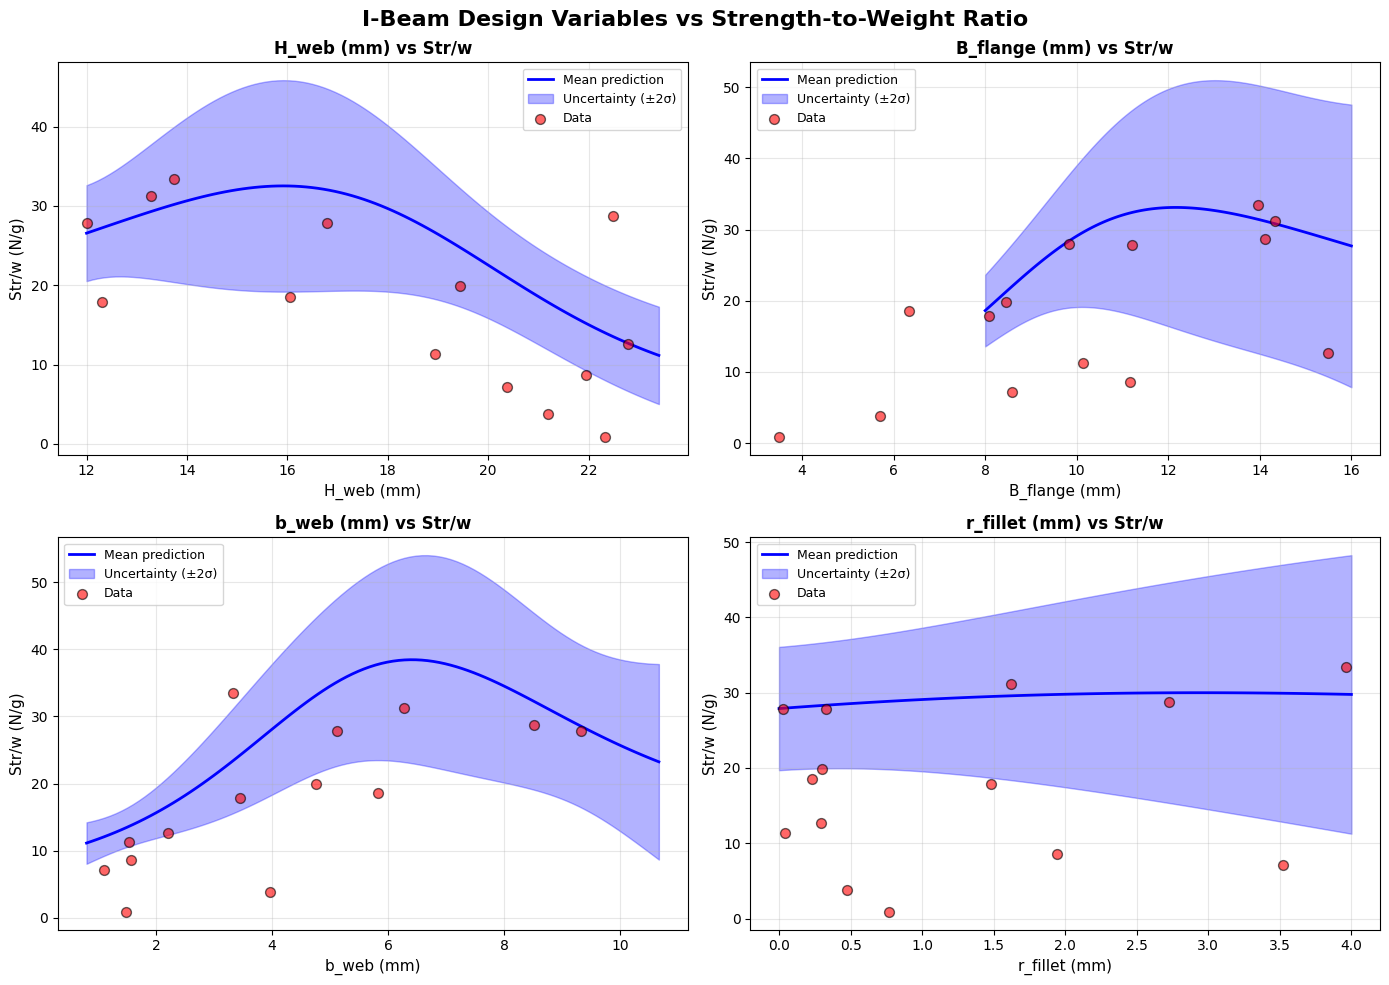

✓ 1D plots complete

Generating 2D contour plots (global averages)...


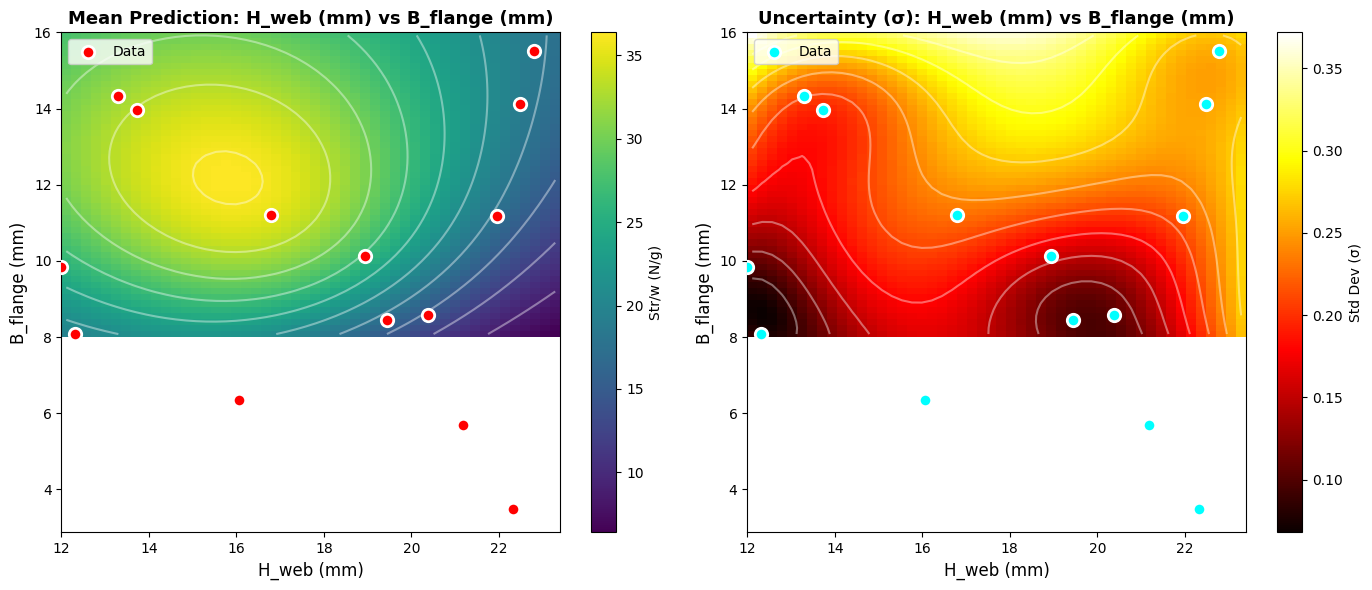

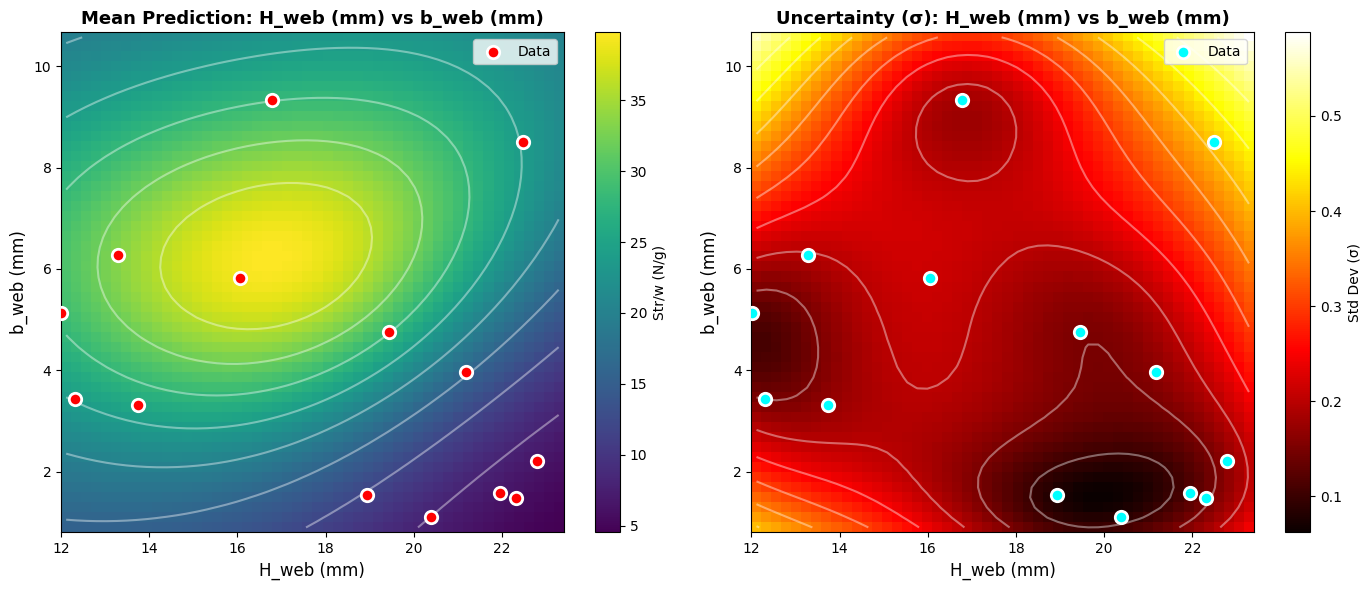

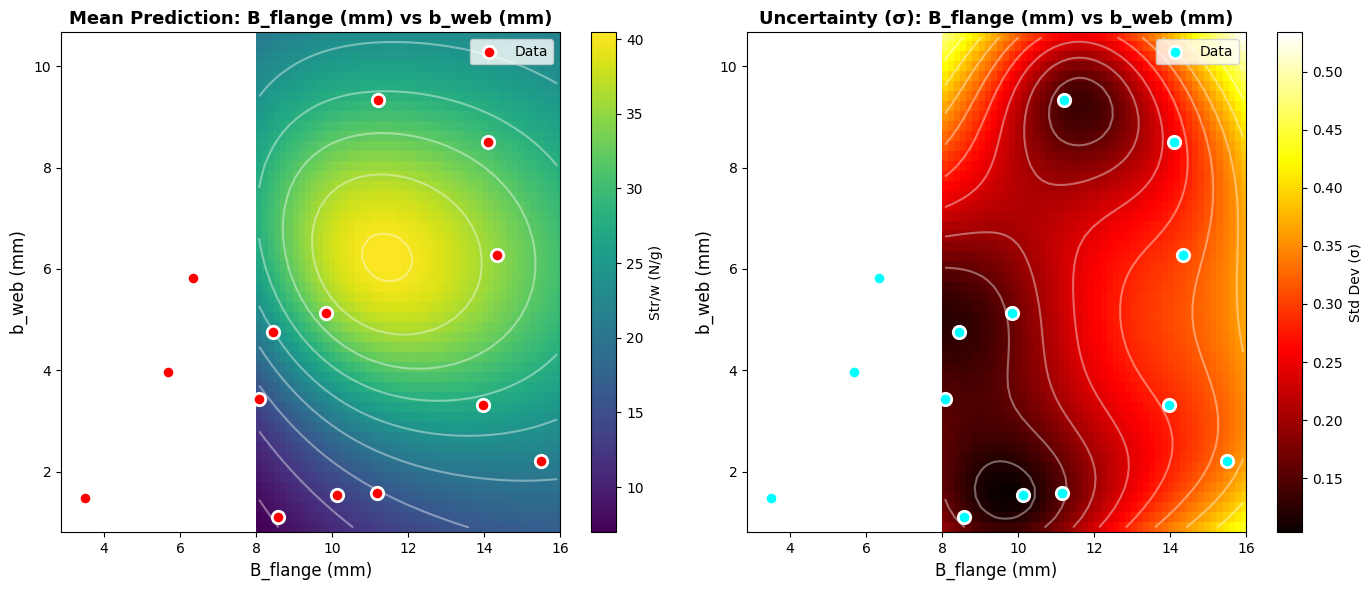

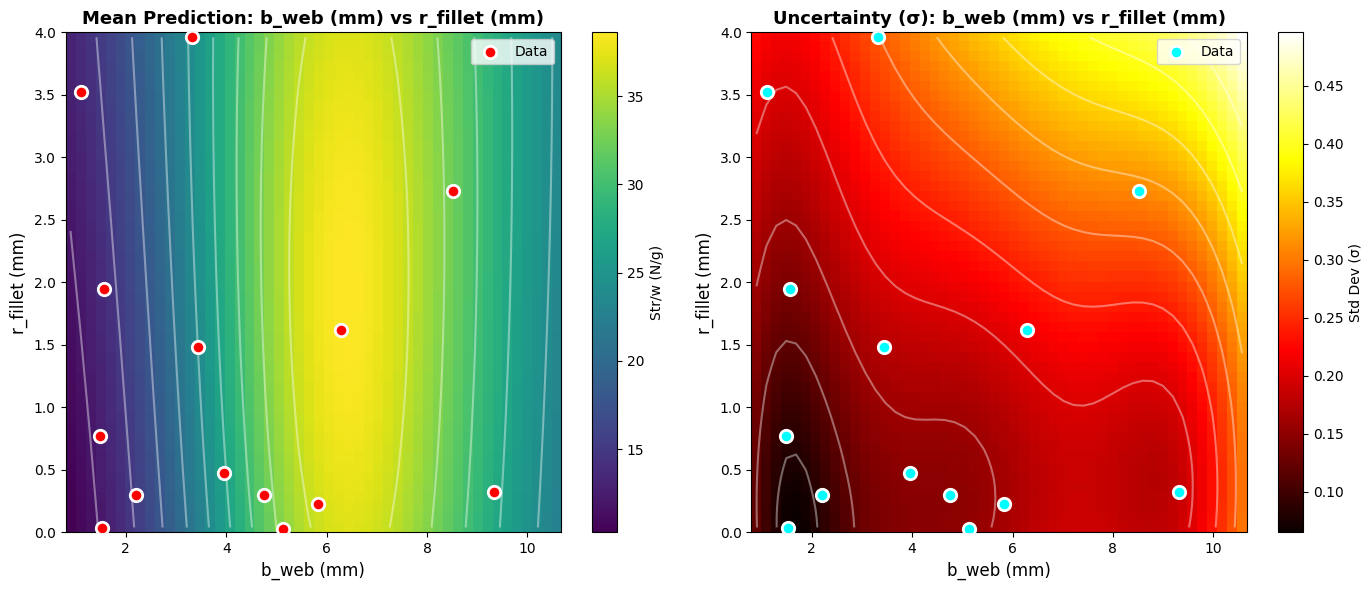


✓ Global plots complete!

Generating slice plots...

Generating 3 slice plot sets...
  Plotting slice: Top #1 (Str/w=33.45)
    Point distribution by proximity:
      Very close (<0.15): 1
      Close (0.15-0.30): 0
      Moderate (0.30-0.50): 0
      Far (0.50-0.75): 1
      Very far (>0.75): 12


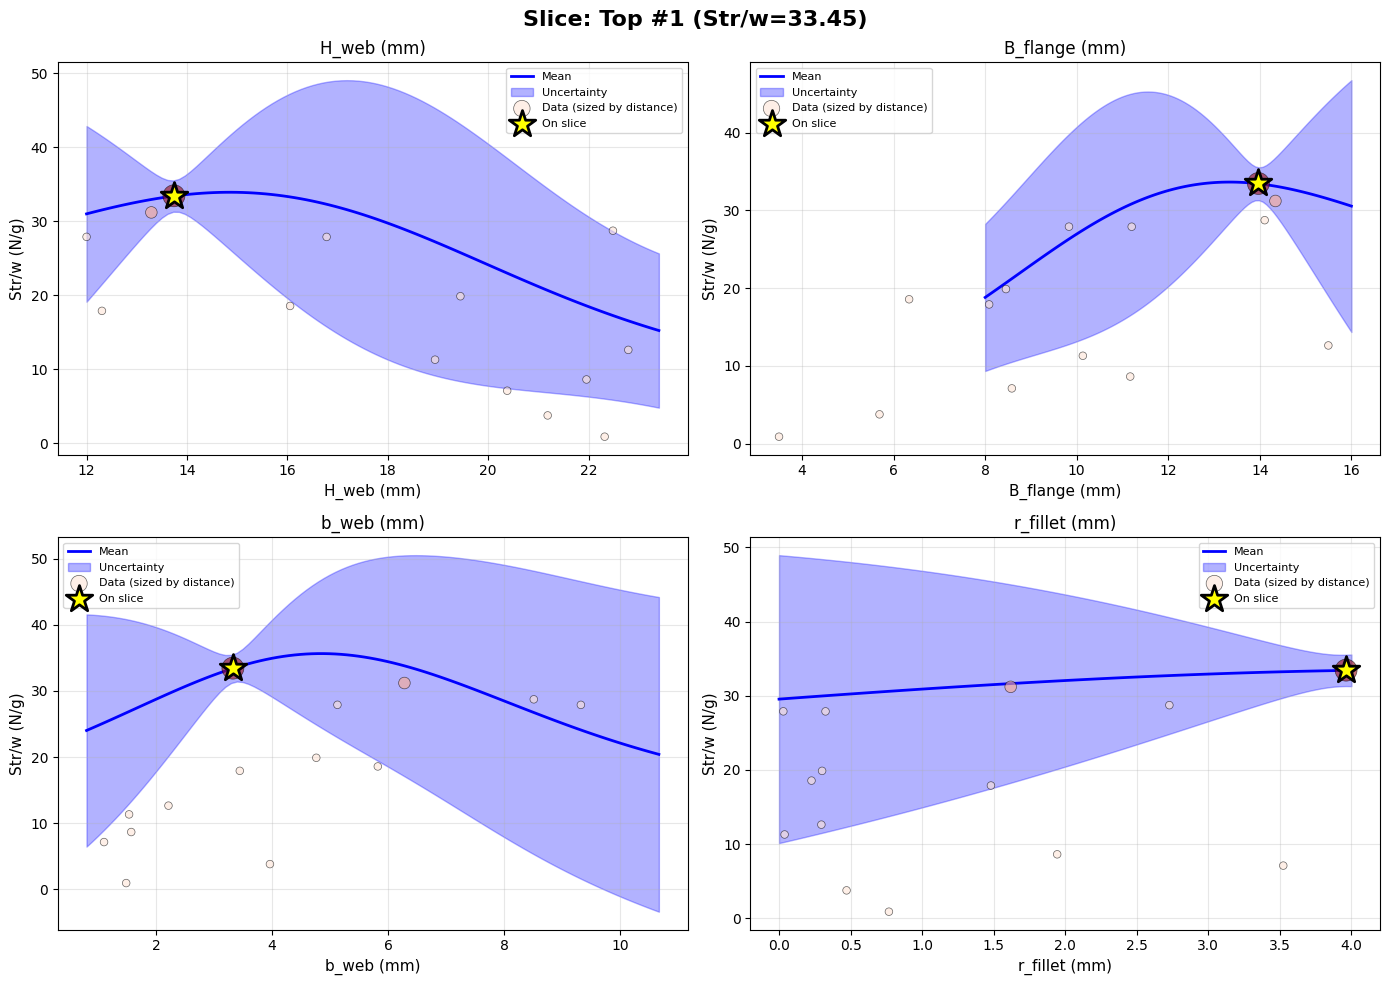

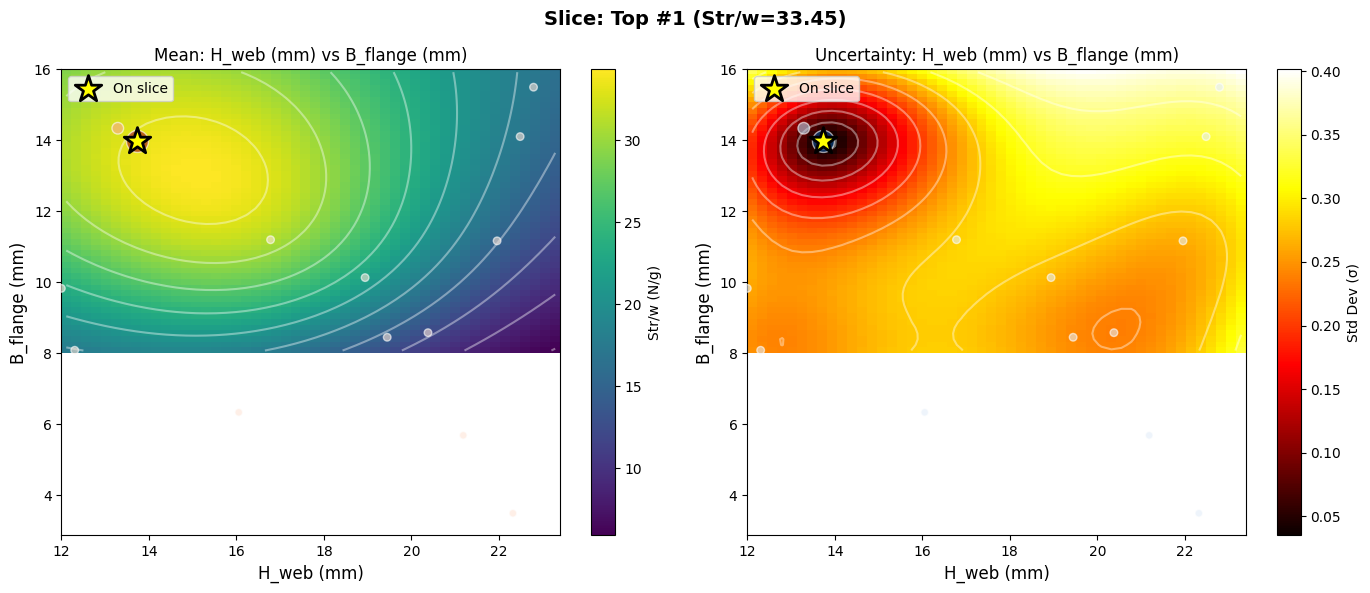

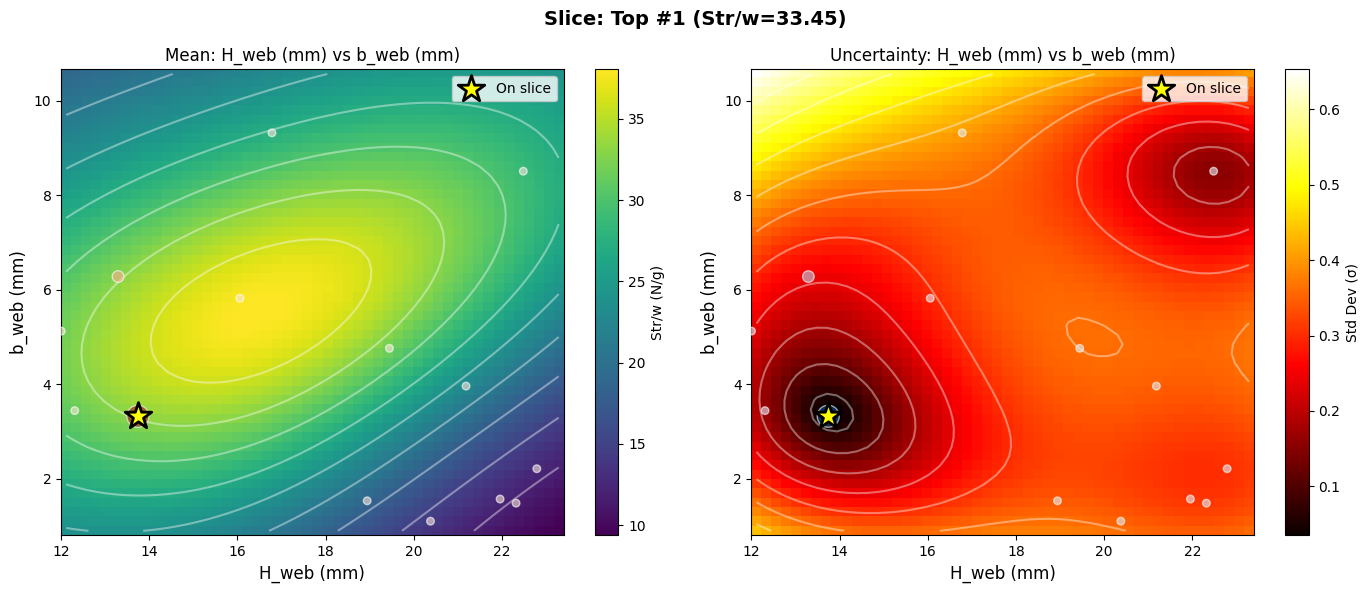

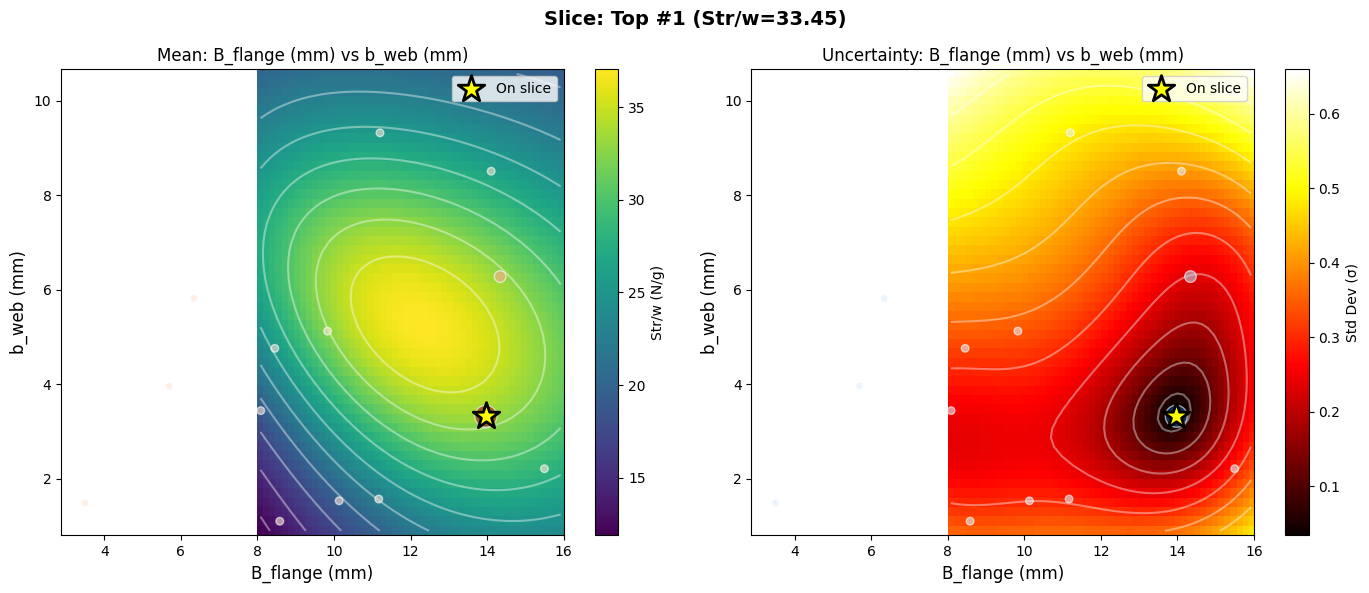

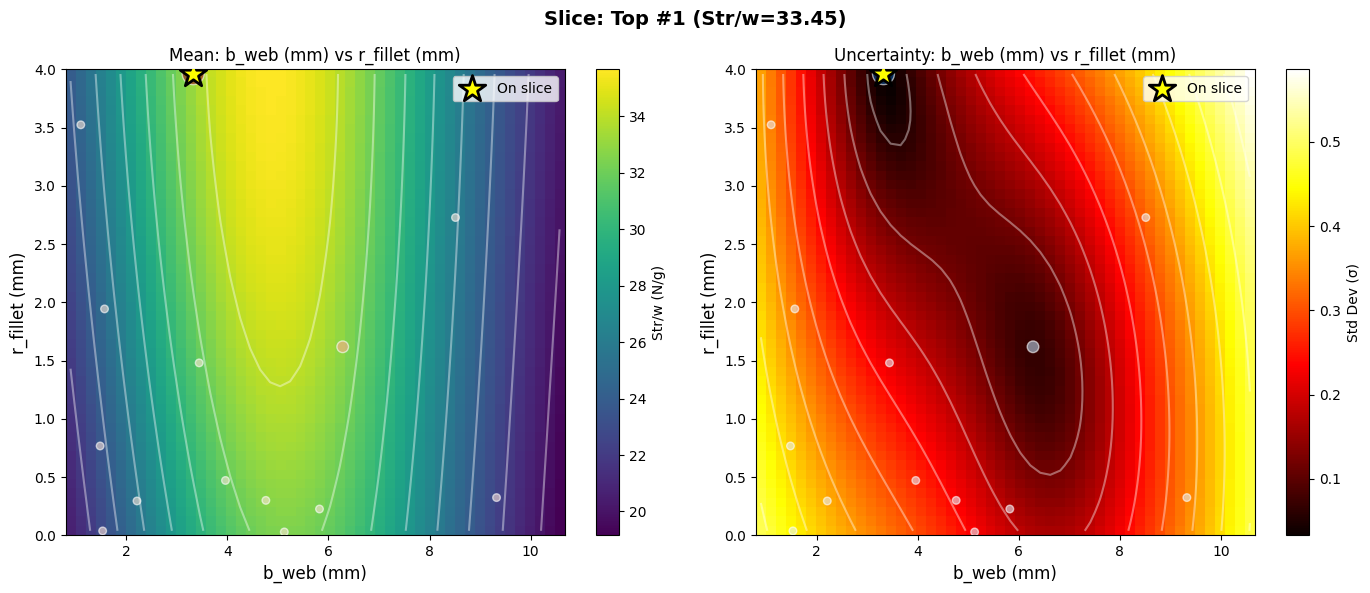

  Plotting slice: Top #2 (Str/w=31.20)
    Point distribution by proximity:
      Very close (<0.15): 1
      Close (0.15-0.30): 0
      Moderate (0.30-0.50): 0
      Far (0.50-0.75): 3
      Very far (>0.75): 10


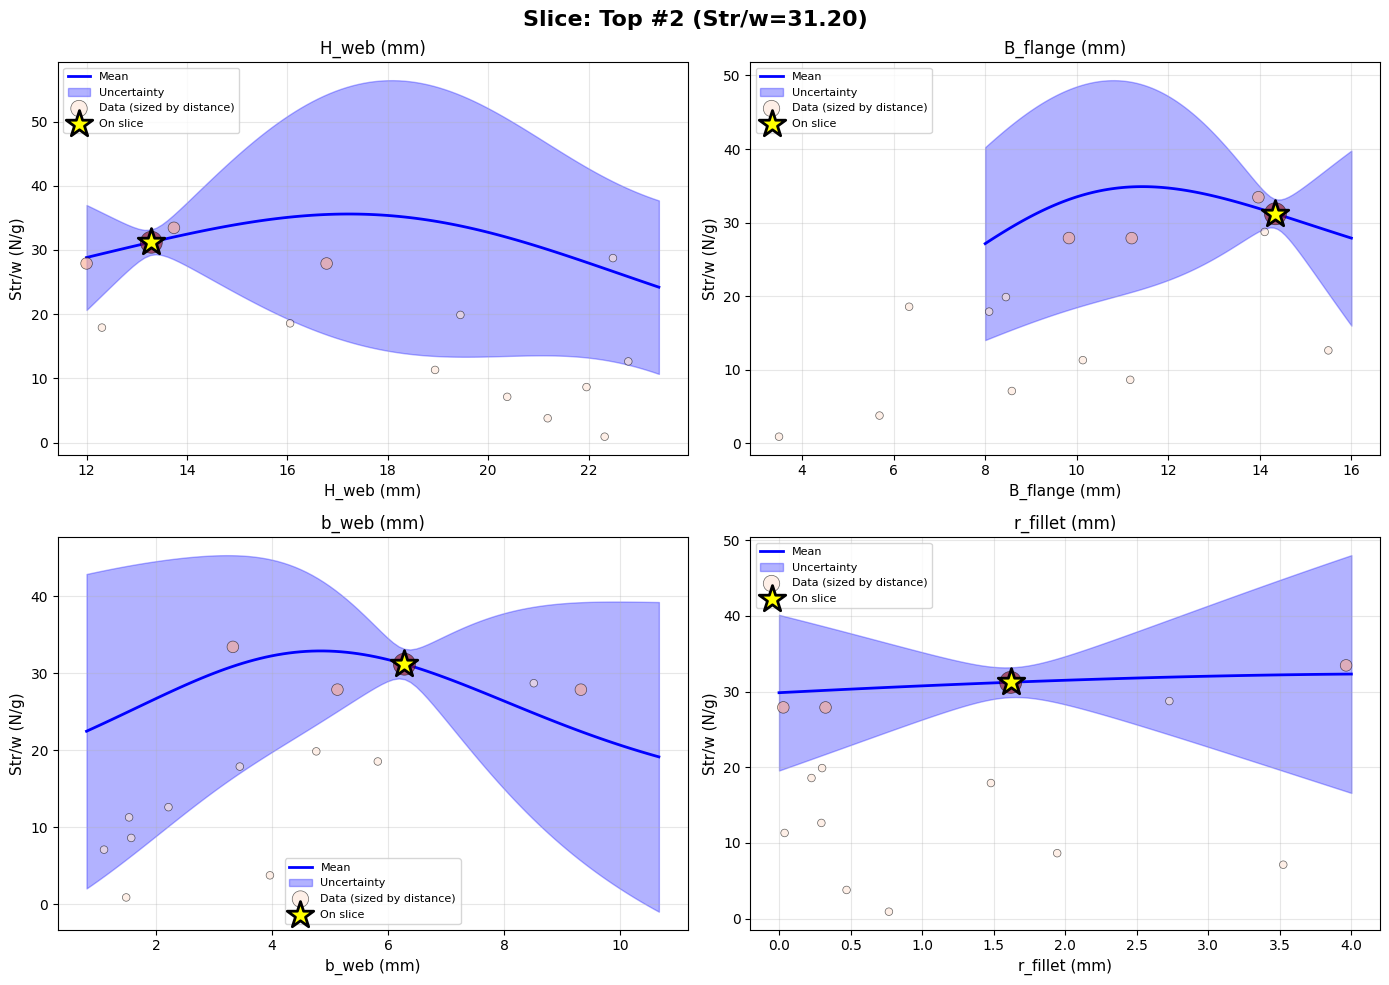

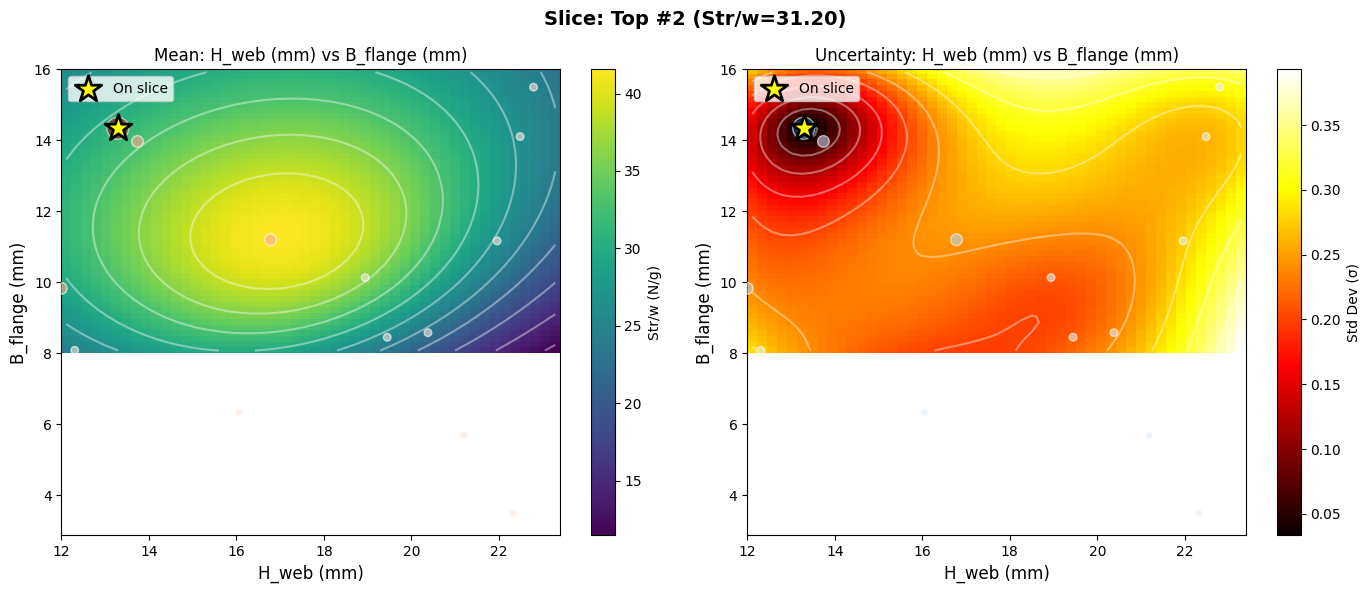

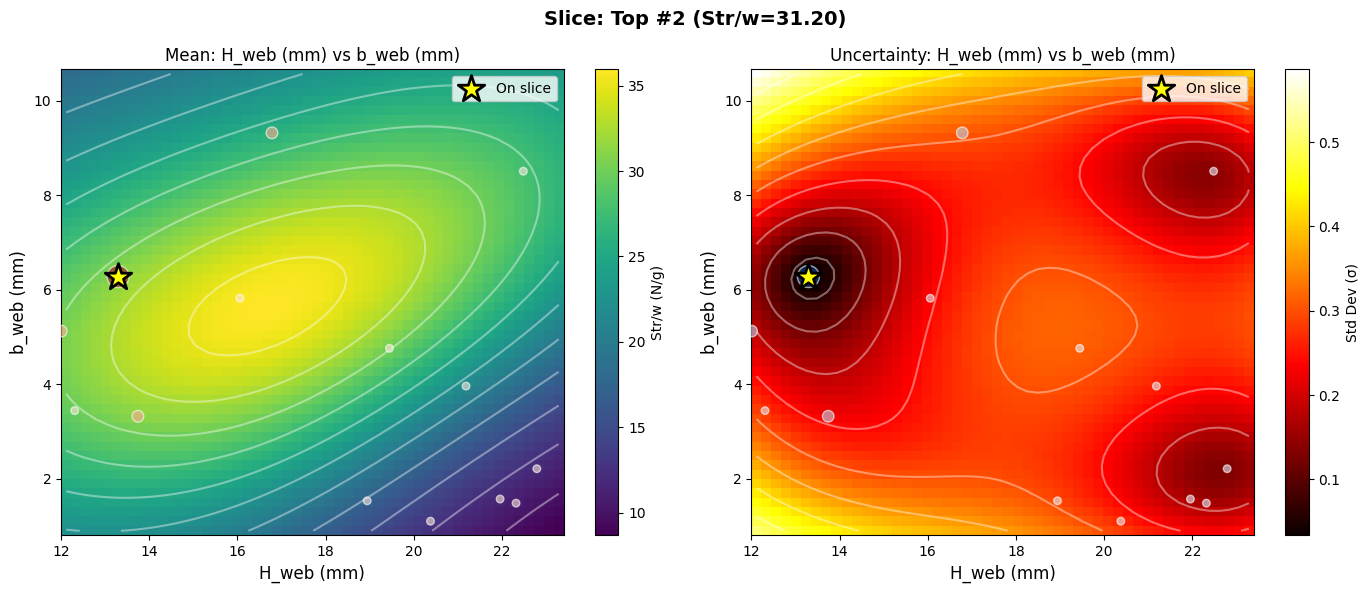

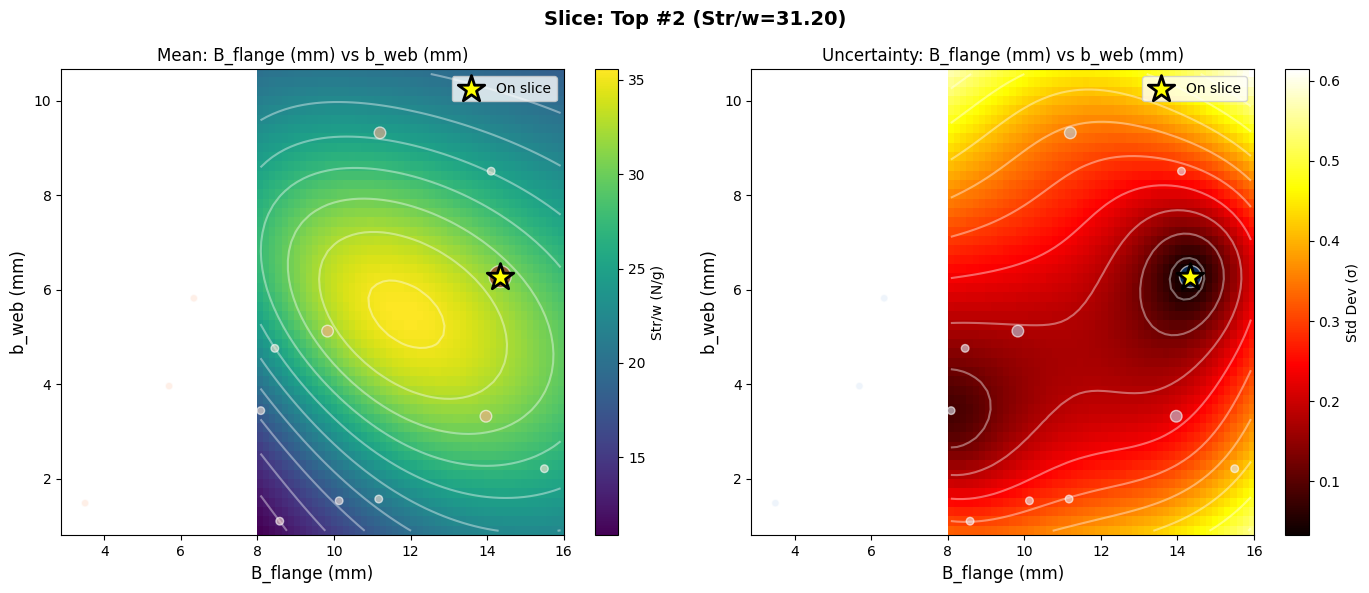

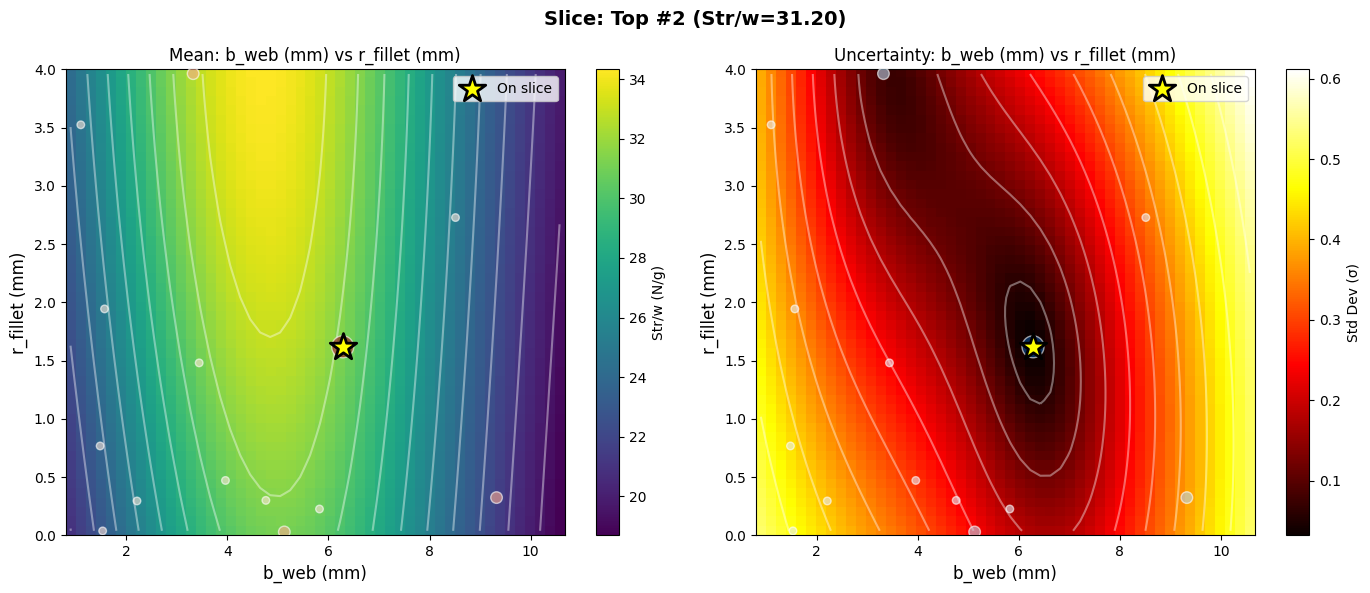

  Plotting slice: Top #3 (Str/w=28.73)
    Point distribution by proximity:
      Very close (<0.15): 1
      Close (0.15-0.30): 0
      Moderate (0.30-0.50): 0
      Far (0.50-0.75): 0
      Very far (>0.75): 13


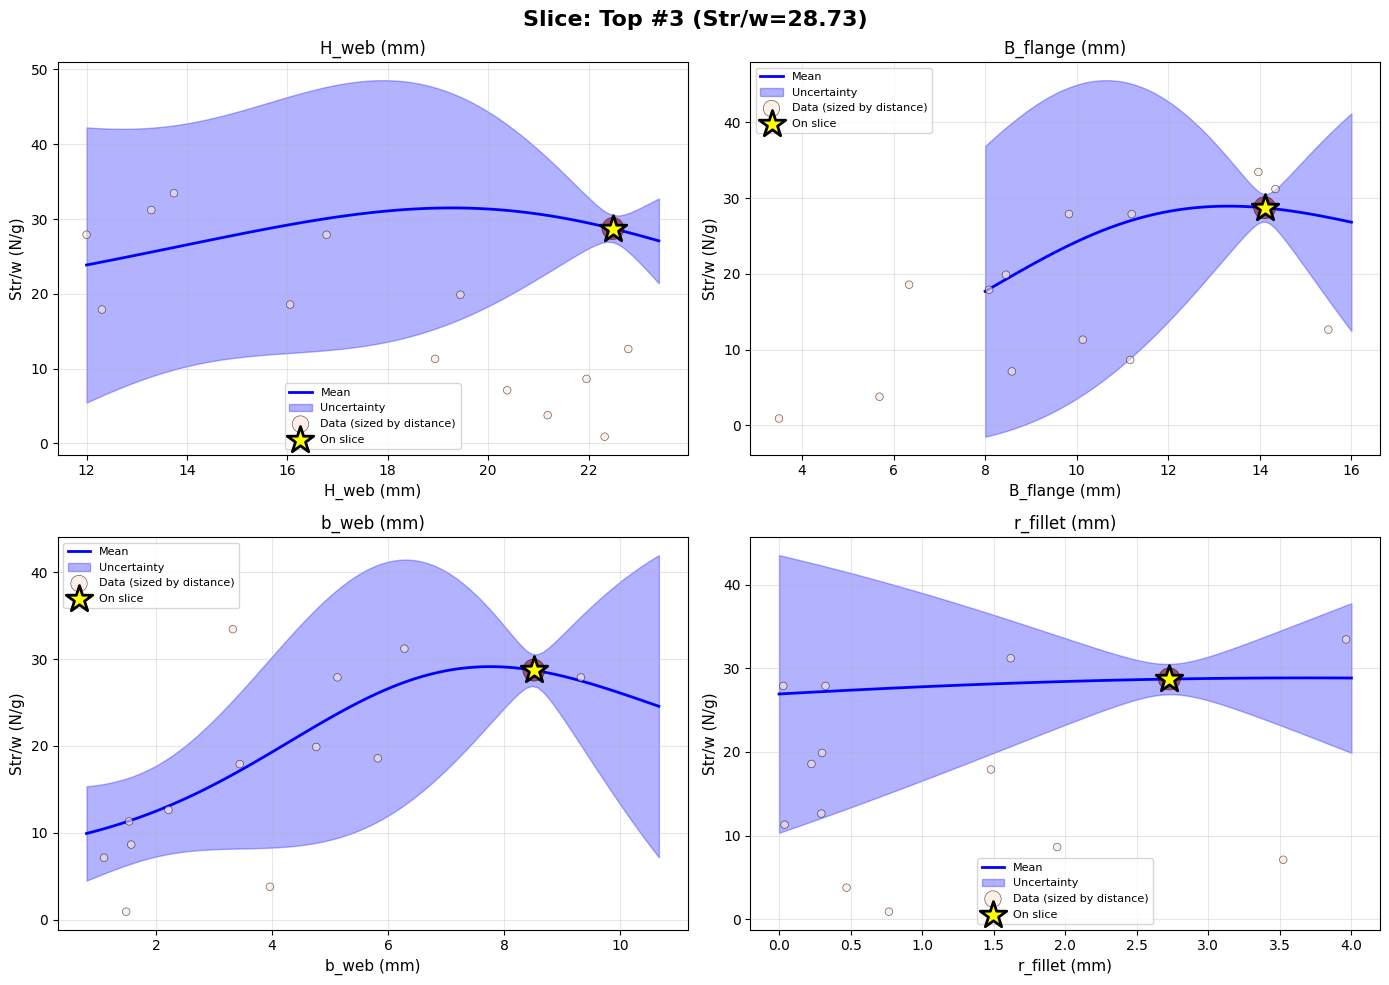

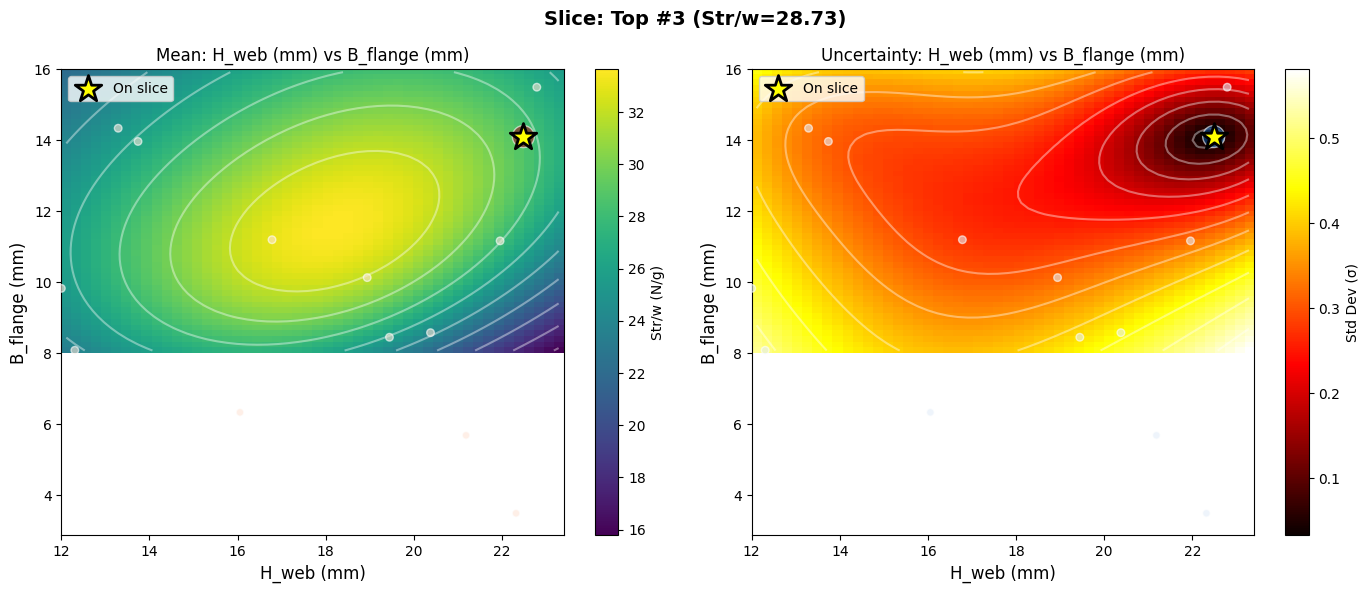

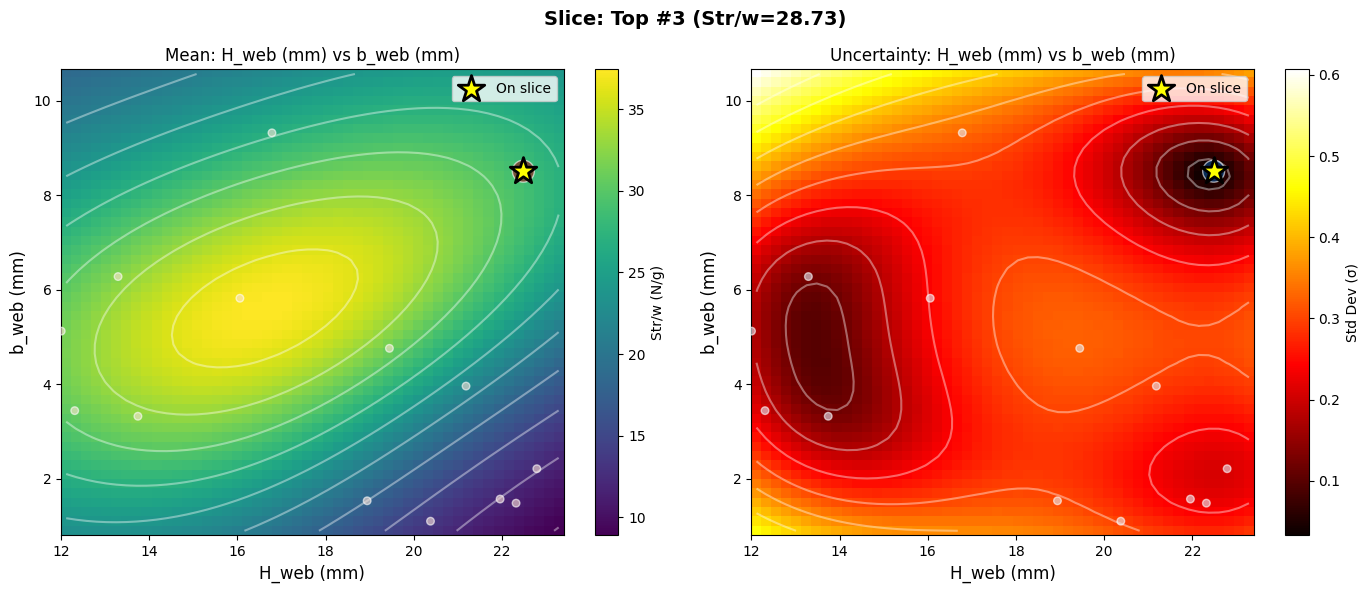

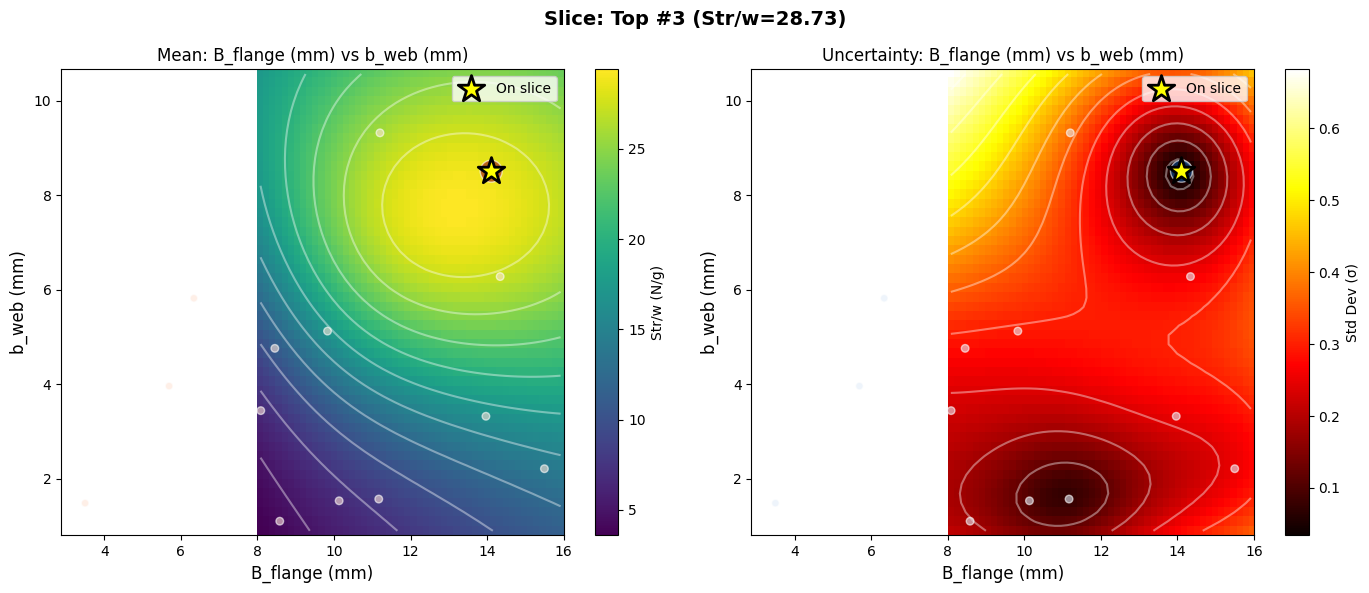

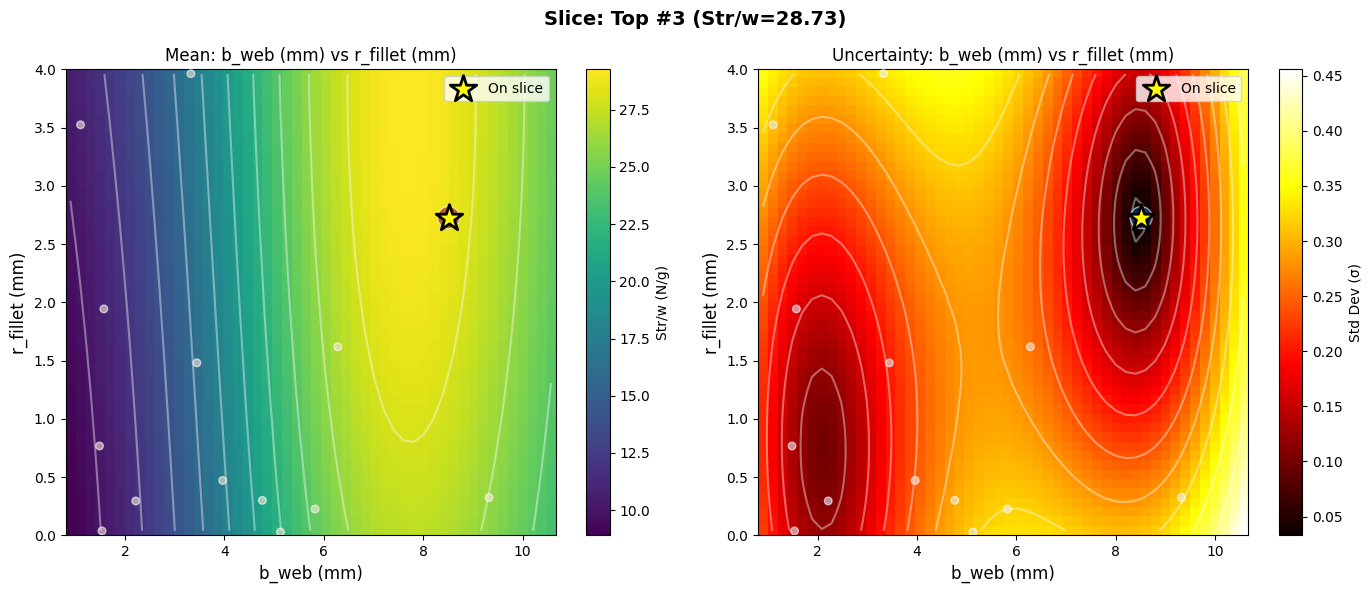


✓ ALL I-BEAM PLOTS COMPLETE!
Generated plots:
  - 1 global 1D plot (4 subplots)
  - 4 global 2D contour pairs
  - 3 slice-specific plot sets
  Total: 20 figures


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from matplotlib.patches import Circle
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION - I-BEAM SPECIFIC
# ==========================================
CSV_FILE = "I_beam_data.csv"  # Your I-beam data file

# Column mapping for I-beam data
COL_MAP = {
    'H': 'H_web_height',
    'B': 'B_flange_width',
    'b': 'b_web_thick',
    'r': 'r_fillet',
    'target': 'Str/w (N/g)',
}

# Design space bounds (4D)
BOUNDS = {
    'H': (12.0, 23.4),
    'B': (8.0, 16.0),
    'b': (0.8, 10.67),
    'r': (0.0, 4.0)
}

PARAM_NAMES = ['H_web (mm)', 'B_flange (mm)', 'b_web (mm)', 'r_fillet (mm)']

# GP Configuration
NOISE_LEVEL = 1e-3  # Constant noise in log-space

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def normalize(X, bounds=BOUNDS):
    """Normalize features to [0, 1]"""
    X_n = np.copy(X).astype(float)
    keys = list(bounds.keys())
    for i, k in enumerate(keys):
        X_n[:, i] = (X[:, i] - bounds[k][0]) / (bounds[k][1] - bounds[k][0])
    return X_n

def denormalize(X_n, bounds=BOUNDS):
    """Denormalize features back to original scale"""
    X = np.copy(X_n)
    keys = list(bounds.keys())
    for i, k in enumerate(keys):
        X[:, i] = X_n[:, i] * (bounds[k][1] - bounds[k][0]) + bounds[k][0]
    return X

def get_point_sizes(X_norm, slice_point_norm, max_distance=0.5):
    """
    Compute marker sizes based on distance from slice using buckets.
    Points are categorized into proximity tiers with distinct sizes.
    """
    distances = np.linalg.norm(X_norm - slice_point_norm, axis=1)

    sizes = np.zeros_like(distances)
    colors = np.zeros_like(distances)

    # Assign sizes based on buckets
    bucket1 = distances < 0.15
    bucket2 = (distances >= 0.15) & (distances < 0.30)
    bucket3 = (distances >= 0.30) & (distances < 0.50)
    bucket4 = (distances >= 0.50) & (distances < 0.75)
    bucket5 = distances >= 0.75

    sizes[bucket1] = 250
    sizes[bucket2] = 180
    sizes[bucket3] = 120
    sizes[bucket4] = 70
    sizes[bucket5] = 30

    colors[bucket1] = 0.9
    colors[bucket2] = 0.7
    colors[bucket3] = 0.5
    colors[bucket4] = 0.3
    colors[bucket5] = 0.1

    return sizes, distances, colors

# ==========================================
# LOAD DATA & TRAIN GP
# ==========================================
print("Loading I-beam data and training GP...")
df = pd.read_csv(CSV_FILE)
X = df[[COL_MAP['H'], COL_MAP['B'], COL_MAP['b'], COL_MAP['r']]].values
y = df[COL_MAP['target']].values.astype(float)

print(f"✓ Loaded {len(X)} I-beam samples")
print(f"  Str/w range: [{y.min():.2f}, {y.max():.2f}] N/g")

X_norm = normalize(X)
y_log = np.log(y)
y_mean = np.mean(y_log)
y_centered = y_log - y_mean

# Train GP with constant noise (no input-dependent noise for I-beams)
kernel = ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0)) * Matern(
    length_scale=[0.5]*4,
    length_scale_bounds=(0.1, 3.0),
    nu=2.5
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    alpha=NOISE_LEVEL,  # Constant noise
    normalize_y=False
)
gp.fit(X_norm, y_centered)

print("✓ GP trained successfully")
print(f"  Kernel: {gp.kernel_}")
print(f"  Noise level: {NOISE_LEVEL:.1e}")

# Try to load BO recommendations
try:
    rec_norm = np.load("bo_recommendations_norm.npy")
    rec_labels = np.load("bo_labels.npy", allow_pickle=True)
    HAS_RECOMMENDATIONS = True
    print(f"✓ Loaded {len(rec_norm)} BO recommendations")
except:
    HAS_RECOMMENDATIONS = False
    print("⚠️ No recommendations found - plotting data only")

# ==========================================
# 1D PLOTS: EACH VARIABLE VS STR/W
# ==========================================
print("\nGenerating 1D plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.suptitle('I-Beam Design Variables vs Strength-to-Weight Ratio',
             fontsize=16, fontweight='bold')

for dim in range(4):
    ax = axes[dim]

    n_test = 100
    X_test_norm = np.tile(np.mean(X_norm, axis=0), (n_test, 1))
    X_test_norm[:, dim] = np.linspace(0, 1, n_test)

    mu, sigma = gp.predict(X_test_norm, return_std=True)
    mu_real = np.exp(mu + y_mean)
    std_real = np.exp(mu + y_mean) * sigma

    X_test_denorm = denormalize(X_test_norm)
    x_vals = X_test_denorm[:, dim]

    ax.plot(x_vals, mu_real, 'b-', linewidth=2, label='Mean prediction')
    aleatory_std = np.exp(mu + y_mean) * np.sqrt(NOISE_LEVEL)
    total_std = np.sqrt(std_real**2 + aleatory_std**2)
    ax.fill_between(x_vals, mu_real - 2*total_std, mu_real + 2*total_std,
                     alpha=0.25, color='orange', label='Aleatory (±2σ)')
    ax.fill_between(x_vals, mu_real - 2*std_real, mu_real + 2*std_real,
                     alpha=0.3, color='blue', label='Epistemic (±2σ)')

    X_denorm = denormalize(X_norm)
    ax.scatter(X_denorm[:, dim], y, c='red', s=50, alpha=0.6, edgecolors='black',
               linewidths=1, label='Data', zorder=5)

    ax.set_xlabel(PARAM_NAMES[dim], fontsize=11)
    ax.set_ylabel('Str/w (N/g)', fontsize=11)
    ax.set_title(f'{PARAM_NAMES[dim]} vs Str/w', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ibeam_1d_plots_all_params.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 1D plots complete")

# ==========================================
# 2D CONTOUR PLOTS: GLOBAL AVERAGES
# ==========================================
print("\nGenerating 2D contour plots (global averages)...")

# Interesting parameter combinations for I-beams
combos = [
    (0, 1, 'H_web (mm)', 'B_flange (mm)'),      # H vs B - primary geometry
    (0, 2, 'H_web (mm)', 'b_web (mm)'),         # H vs b - height vs thickness
    (1, 2, 'B_flange (mm)', 'b_web (mm)'),      # B vs b - width vs thickness
    (2, 3, 'b_web (mm)', 'r_fillet (mm)')       # b vs r - thickness vs fillet
]

for dim1, dim2, name1, name2 in combos:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    res = 50
    grid_x = np.linspace(0, 1, res)
    grid_y = np.linspace(0, 1, res)
    X_grid, Y_grid = np.meshgrid(grid_x, grid_y)

    X_test = np.tile(np.mean(X_norm, axis=0), (res*res, 1))
    X_test[:, dim1] = X_grid.ravel()
    X_test[:, dim2] = Y_grid.ravel()

    mu, sigma = gp.predict(X_test, return_std=True)
    mu_real = np.exp(mu + y_mean).reshape(res, res)
    sigma_real = sigma.reshape(res, res)

    keys = list(BOUNDS.keys())
    x_vals = grid_x * (BOUNDS[keys[dim1]][1] - BOUNDS[keys[dim1]][0]) + BOUNDS[keys[dim1]][0]
    y_vals = grid_y * (BOUNDS[keys[dim2]][1] - BOUNDS[keys[dim2]][0]) + BOUNDS[keys[dim2]][0]
    extent = [x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]]

    # Mean prediction plot
    im1 = axes[0].imshow(mu_real, origin='lower', extent=extent, aspect='auto', cmap='viridis')
    axes[0].contour(mu_real, origin='lower', extent=extent, colors='white', alpha=0.4, levels=10)
    axes[0].set_xlabel(name1, fontsize=12)
    axes[0].set_ylabel(name2, fontsize=12)
    axes[0].set_title(f'Mean Prediction: {name1} vs {name2}', fontsize=13, fontweight='bold')

    X_denorm = denormalize(X_norm)
    axes[0].scatter(X_denorm[:, dim1], X_denorm[:, dim2], c='red', s=80,
                   edgecolors='white', linewidths=2, label='Data', zorder=10)

    if HAS_RECOMMENDATIONS:
        rec_denorm = denormalize(rec_norm)
        axes[0].scatter(rec_denorm[:, dim1], rec_denorm[:, dim2], c='lime', s=150,
                       marker='*', edgecolors='black', linewidths=1.5,
                       label='BO Recommendations', zorder=11)

    axes[0].legend()
    plt.colorbar(im1, ax=axes[0], label='Str/w (N/g)')

    # Uncertainty plot
    im2 = axes[1].imshow(sigma_real, origin='lower', extent=extent, aspect='auto', cmap='hot')
    axes[1].contour(sigma_real, origin='lower', extent=extent, colors='white', alpha=0.4, levels=10)
    axes[1].set_xlabel(name1, fontsize=12)
    axes[1].set_ylabel(name2, fontsize=12)
    axes[1].set_title(f'Uncertainty (σ): {name1} vs {name2}', fontsize=13, fontweight='bold')
    axes[1].scatter(X_denorm[:, dim1], X_denorm[:, dim2], c='cyan', s=80,
                   edgecolors='white', linewidths=2, label='Data', zorder=10)
    if HAS_RECOMMENDATIONS:
        axes[1].scatter(rec_denorm[:, dim1], rec_denorm[:, dim2], c='lime', s=150,
                       marker='*', edgecolors='black', linewidths=1.5,
                       label='BO Recommendations', zorder=11)
    axes[1].legend()
    plt.colorbar(im2, ax=axes[1], label='Std Dev (σ)')

    plt.tight_layout()
    safe_name1 = name1.split()[0].replace('_', '')
    safe_name2 = name2.split()[0].replace('_', '')
    plt.savefig(f'ibeam_2d_contour_{safe_name1}_{safe_name2}_global.png',
                dpi=150, bbox_inches='tight')
    plt.show()

print("\n✓ Global plots complete!")

# ==========================================
# SLICE PLOTS
# ==========================================
print("\nGenerating slice plots...")

def plot_slice(slice_point_norm, slice_name, slice_idx):
    """Generate all plots for a specific slice"""

    print(f"  Plotting slice: {slice_name}")

    clean_name = slice_name.replace('#', 'num').replace('(', '').replace(')', '') \
                          .replace('=', '').replace(':', '').replace('/', '_').replace(' ', '_')

    point_sizes, point_distances, point_colors = get_point_sizes(X_norm, slice_point_norm)
    on_slice = point_distances < 0.1

    print(f"    Point distribution by proximity:")
    print(f"      Very close (<0.15): {np.sum(point_distances < 0.15)}")
    print(f"      Close (0.15-0.30): {np.sum((point_distances >= 0.15) & (point_distances < 0.30))}")
    print(f"      Moderate (0.30-0.50): {np.sum((point_distances >= 0.30) & (point_distances < 0.50))}")
    print(f"      Far (0.50-0.75): {np.sum((point_distances >= 0.50) & (point_distances < 0.75))}")
    print(f"      Very far (>0.75): {np.sum(point_distances >= 0.75)}")

    # 1D Plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    fig.suptitle(f'Slice: {slice_name}', fontsize=16, fontweight='bold')

    for dim in range(4):
        ax = axes[dim]

        n_test = 100
        X_test_norm = np.tile(slice_point_norm, (n_test, 1))
        X_test_norm[:, dim] = np.linspace(0, 1, n_test)

        mu, sigma = gp.predict(X_test_norm, return_std=True)
        mu_real = np.exp(mu + y_mean)
        std_real = np.exp(mu + y_mean) * sigma

        X_test_denorm = denormalize(X_test_norm)
        x_vals = X_test_denorm[:, dim]

        ax.plot(x_vals, mu_real, 'b-', linewidth=2, label='Mean')
        aleatory_std = np.exp(mu + y_mean) * np.sqrt(NOISE_LEVEL)
        total_std = np.sqrt(std_real**2 + aleatory_std**2)
        ax.fill_between(x_vals, mu_real - 2*total_std, mu_real + 2*total_std,
                         alpha=0.25, color='orange', label='Aleatory')
        ax.fill_between(x_vals, mu_real - 2*std_real, mu_real + 2*std_real,
                         alpha=0.3, color='blue', label='Epistemic')

        X_denorm = denormalize(X_norm)
        scatter = ax.scatter(X_denorm[:, dim], y, s=point_sizes,
                            c=point_colors, cmap='Reds', vmin=0, vmax=1,
                            alpha=0.6, edgecolors='black', linewidths=0.5,
                            zorder=5, label='Data (sized by distance)')

        if np.any(on_slice):
            ax.scatter(X_denorm[on_slice, dim], y[on_slice], s=400, marker='*',
                      c='yellow', edgecolors='black', linewidths=2, zorder=10,
                      label='On slice')

        ax.set_xlabel(PARAM_NAMES[dim], fontsize=11)
        ax.set_ylabel('Str/w (N/g)', fontsize=11)
        ax.set_title(f'{PARAM_NAMES[dim]}', fontsize=12)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'ibeam_slice_{slice_idx:02d}_{clean_name}_1d.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # 2D Contours
    for dim1, dim2, name1, name2 in combos:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(f'Slice: {slice_name}', fontsize=14, fontweight='bold')

        res = 50
        grid_x = np.linspace(0, 1, res)
        grid_y = np.linspace(0, 1, res)
        X_grid, Y_grid = np.meshgrid(grid_x, grid_y)

        X_test = np.tile(slice_point_norm, (res*res, 1))
        X_test[:, dim1] = X_grid.ravel()
        X_test[:, dim2] = Y_grid.ravel()

        mu, sigma = gp.predict(X_test, return_std=True)
        mu_real = np.exp(mu + y_mean).reshape(res, res)
        sigma_real = sigma.reshape(res, res)

        keys = list(BOUNDS.keys())
        x_vals = grid_x * (BOUNDS[keys[dim1]][1] - BOUNDS[keys[dim1]][0]) + BOUNDS[keys[dim1]][0]
        y_vals = grid_y * (BOUNDS[keys[dim2]][1] - BOUNDS[keys[dim2]][0]) + BOUNDS[keys[dim2]][0]
        extent = [x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]]

        im1 = axes[0].imshow(mu_real, origin='lower', extent=extent, aspect='auto', cmap='viridis')
        axes[0].contour(mu_real, origin='lower', extent=extent, colors='white', alpha=0.4, levels=10)
        axes[0].set_xlabel(name1, fontsize=12)
        axes[0].set_ylabel(name2, fontsize=12)
        axes[0].set_title(f'Mean: {name1} vs {name2}', fontsize=12)

        X_denorm = denormalize(X_norm)
        axes[0].scatter(X_denorm[:, dim1], X_denorm[:, dim2], s=point_sizes,
                       c=point_colors, cmap='Reds', vmin=0, vmax=1,
                       alpha=0.6, edgecolors='white', linewidths=1, zorder=5)

        if np.any(on_slice):
            axes[0].scatter(X_denorm[on_slice, dim1], X_denorm[on_slice, dim2],
                           s=400, marker='*', c='yellow', edgecolors='black',
                           linewidths=2, zorder=10, label='On slice')
            axes[0].legend()

        plt.colorbar(im1, ax=axes[0], label='Str/w (N/g)')

        im2 = axes[1].imshow(sigma_real, origin='lower', extent=extent, aspect='auto', cmap='hot')
        axes[1].contour(sigma_real, origin='lower', extent=extent, colors='white', alpha=0.4, levels=10)
        axes[1].set_xlabel(name1, fontsize=12)
        axes[1].set_ylabel(name2, fontsize=12)
        axes[1].set_title(f'Uncertainty: {name1} vs {name2}', fontsize=12)

        axes[1].scatter(X_denorm[:, dim1], X_denorm[:, dim2], s=point_sizes,
                       c=point_colors, cmap='Blues', vmin=0, vmax=1,
                       alpha=0.6, edgecolors='white', linewidths=1, zorder=5)

        if np.any(on_slice):
            axes[1].scatter(X_denorm[on_slice, dim1], X_denorm[on_slice, dim2],
                           s=400, marker='*', c='yellow', edgecolors='black',
                           linewidths=2, zorder=10, label='On slice')
            axes[1].legend()

        plt.colorbar(im2, ax=axes[1], label='Std Dev (σ)')

        plt.tight_layout()
        safe_name1 = name1.split()[0].replace('_', '')
        safe_name2 = name2.split()[0].replace('_', '')
        plt.savefig(f'ibeam_slice_{slice_idx:02d}_{clean_name}_{safe_name1}_{safe_name2}.png',
                   dpi=150, bbox_inches='tight')
        plt.show()

# Define slices
slices = []

# Top 3 performing I-beams
top3_indices = np.argsort(y)[-3:][::-1]
for i, idx in enumerate(top3_indices):
    slice_name = f"Top #{i+1} (Str/w={y[idx]:.2f})"
    slices.append((X_norm[idx], slice_name))

# BO recommendations (if available)
if HAS_RECOMMENDATIONS:
    for i, (point, label) in enumerate(zip(rec_norm, rec_labels)):
        slice_name = f"Rec: {label}"
        slices.append((point, slice_name))

print(f"\nGenerating {len(slices)} slice plot sets...")
for idx, (slice_point, slice_name) in enumerate(slices):
    plot_slice(slice_point, slice_name, idx)

print("\n" + "="*70)
print("✓ ALL I-BEAM PLOTS COMPLETE!")
print("="*70)
print(f"Generated plots:")
print(f"  - 1 global 1D plot (4 subplots)")
print(f"  - {len(combos)} global 2D contour pairs")
print(f"  - {len(slices)} slice-specific plot sets")
print(f"  Total: {1 + len(combos) + len(slices) * (1 + len(combos))} figures")
print("="*70)